# Linear Regression

## Motivation & Overview

### Testing Conditional Dependence

Up to this point, we have focused on testing associations between pairs of variables. However, in data science applications, it is very common to study three or more variables jointly.

For pairs of variables, say $x$
 and $y$
, one variable may be considered as the explanatory variable (let us take $x$
) and the other the response variable ($y$). 

Asking whether $y$
 depends on $x$
 amounts to ask whether the conditional distribution of $y$
 given $x$
 varies when $x$ 
 varies. 

For instance, one may state that body height depends on sex by showing that the distribution of body heights is not same among males than among females. In general statistical terms, testing for independence can be expressed as the null hypothesis:

$H_0: p(y | x) = p(y)$

Let us assume now we are considering multiple explanatory variables $x_1, x_2, ..., x_p$ and a response variable $y$.

We are still interested in the association of one particular explanatory variable, say $x_j$
 with the response variable $y$
 but shall take into consideration all the other explanatory variables.

 In other words, we would like to know whether $y$
 depends on $x_j$
 everything else being the same.

For instance, we may observe that drinking coffee positively correlates with lung cancer, but, neither among smokers, nor among non-smokers, drinking coffee associates with lung cancer.

In this example, everything else being same (i.e. for same smoking status), there is no association between lung cancer and drinking coffee. In this thought experiment, the association found in the overall population probably comes from the fact that smokers tend to be coffee drinkers. 

 Generally, we ask whether the conditional distribution of $y$ 
 given all explanatory variables varies when $x_j$
 alone varies.

Hence, to move beyond pairs of variables, we need a strategy to assess null hypotheses such as:

$H_0: p(y | x_1, ..., x_j, ..., x_p) = p(y | x_1, ..., x_{j-1}, x_{j+1}, ..., x_p)$

Considered so generally, i.e. for any type of variable $y$
 and for any number and types of explanatory variables $x_1, ..., x_p$
, the null hypothesis on above is impractical because:

1. We need to be able to deal with any type of distribution: Gaussian, Binomial, Poisson, but also mixtures, or even distributions that are not functionally parameterized.

2. We need to be able to condition on continuous variables. Conditioning on categorical variables leads to obvious stratification of the data. However, how shall we deal with continuous ones? Shall we do some binning? Based on what criteria? Could the binning strategy affect the results?

3. Even when all variables are categorical, there is a combinatorial explosion of strata, as each stratum gets further split by every new added variables (say by smoking status, and further by sex, and further by diabetes,…). For instance, there are $2^p$
 different strata for $p$ 
 binary variables. This combinatorial explosion makes the analysis difficult. Moreover the statistical power, which is driven by the number of samples in each stratum, gets drastically reduced.

----
### Linear Regression

This Chapter introduces linear regression as an effective way to deal with these three issues. Linear regression addresses these three issues by making the following assumptions:

* The conditional distribution $p(y | x_1, ..., x_p)$
 is a Gaussian distribution whose variance is independent of $x_1, ..., x_p$
, simplifying greatly issue number 1.

* Variables, $x_1, ..., x_p$ are independent.

* The conditional expectation of $y$
 is a simple linear combinations of the explanatory variables, that is:

    $E[y|x_1,...,x_p] = \beta_0 + \beta_1 x_1 + ... + \beta_p x_p \quad \quad (*)$ 

We can think of equation $(*)$ as a simple score of which explanatory variables contribute in a weighted fashion and independently of each other to variations in the expected value of the response.

For instance, one could model the expected body height of an adult as:

$E[\text{height}|\text{sex}, \text{mother}, \text{father}] = 165 + 15 * \text{sex} + 0.5 * (\text{father}-165) + 0.5 * (\text{mother} - 180)$

where sex is $1$ for male and $0$ for female, and mother and father designate each parent’s body height.

The linear model in Equation $(*)$, can deal with continuous as well as discrete explanatory variables, solving the issue number 2. Moreover, because Equation $(*)$ models independent additive contributions of the explanatory variables, it has just one parameter per explanatory variable. These effects do not change between strata. Hence, linear regression does not suffer from a combinatorial explosion of strata (issue number 3).

-----
### Limitations

These assumptions of linear regression make the task easier, but how limiting are they?

* The Gaussian assumption is limiting. We cannot deal with binary response variables for instance. The next chapter will address such cases.

* The assumption that variance is independent of the strata, if violated, can be a problem for fitting this model as well as for statistical testing. We show how to diagnose such issue in later

* The assumption of additivity in Equation $(*)$ seems more limiting than it actually is. 

    First, there are many real-life situations where additivity of the effects of the explanatory variables turns out to be reasonable. Moreover, there is always the possibility to pre-compute non-linear transformations of explanatory variables and include them to the model. For instance this model of expected body weight is a valid linear model with respect to body height cubed – it just needs the cube to be pre-computed:

    $E[\text{weight}|\text{height}] = \beta_0 + \beta_1 \text{height}^3$

All in all, linear regression turns out to be in practice often reasonable.

----

### Applications

Linear regression can be used for various purposes:

* To <u>test conditional dependence</u>. This is done by testing the null hypothesis:
    
    $H_0: \beta_j = 0$


* To <u>estimate the effects of one variable on the response variable.</u> This is done by providing an estimate of the coefficient $\beta_j$.


* To <u>predict</u> the value of the response variable given values of the explanatory variables. The predicted value is then an estimate of the conditional expectation $E[y|x]$.

* To <u>quantify how much variation</u> of a response variable can be explained by a set of explanatory variables.

This Chapter explains first univariate linear regression using a historical dataset of body height. We will then go to the multivariate case using an example from baseball. Finally we will assess what is the practical impact of violations of the modeling assumptions, and how to diagnose them. A substantial part of the Chapter is based on an adaptation of Rafael Irizarry’s book.



-----
## Univariate Regression

### Galton's Height Dataset

We start with linear regression against a single variable, or univariate regression.
<u> Single Variable = Univariate </u>

We use the dataset from which regression was born. 

Francis Galton studied the variation and heredity of human traits.

Among many other traits, Galton collected and studied height data from families to try to understand heredity

While doing this, he developed the concepts of correlation and regression, as well as a connection to pairs of data that follow a normal distribution. A central question Galton explored was the relationship between parents’ heights and the heights of their children.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm

np.random.seed(1983)

galton = pd.read_csv('Datasets/Galton Families.csv')
galton['gender'] = galton['gender'].map({'male':'M', 'female':'F'}) # Change the names of male and female in gender column
galton.drop(columns = ['rownames'], inplace= True) # Drop the unnecessary column
galton.rename(columns= {'gender':'sex'}, inplace=True) # Gender column -> Sex column
galton.head()


,family,father,mother,midparentHeight,children,childNum,sex,childHeight
0,001,78.5,67.0,75.43,4,1,M,73.2
1,001,78.5,67.0,75.43,4,2,F,69.2
2,001,78.5,67.0,75.43,4,3,F,69.0
3,001,78.5,67.0,75.43,4,4,F,69.0
4,002,75.5,66.5,73.66,4,1,M,73.5


In [2]:
galton_male = galton[ galton['sex'] == 'M']
galton_male.head()

,family,father,mother,midparentHeight,children,childNum,sex,childHeight
0,001,78.5,67.0,75.43,4,1,M,73.2
4,002,75.5,66.5,73.66,4,1,M,73.5
5,002,75.5,66.5,73.66,4,2,M,72.5
8,003,75.0,64.0,72.06,2,1,M,71.0
10,004,75.0,64.0,72.06,5,1,M,70.5


In [3]:
# Randomly select one son per family

galton_heights = (
    galton_male
    .groupby('family')
    .sample(n = 1)
    [['father','childHeight']]
    .rename(columns = {'childHeight':'son'})
)

galton_heights.head()

,father,son
0,78.5,73.2
4,75.5,73.5
8,75.0,71.0
11,75.0,68.5
16,75.0,69.0


Plotting clearly shows that the taller the father, the taller the son.

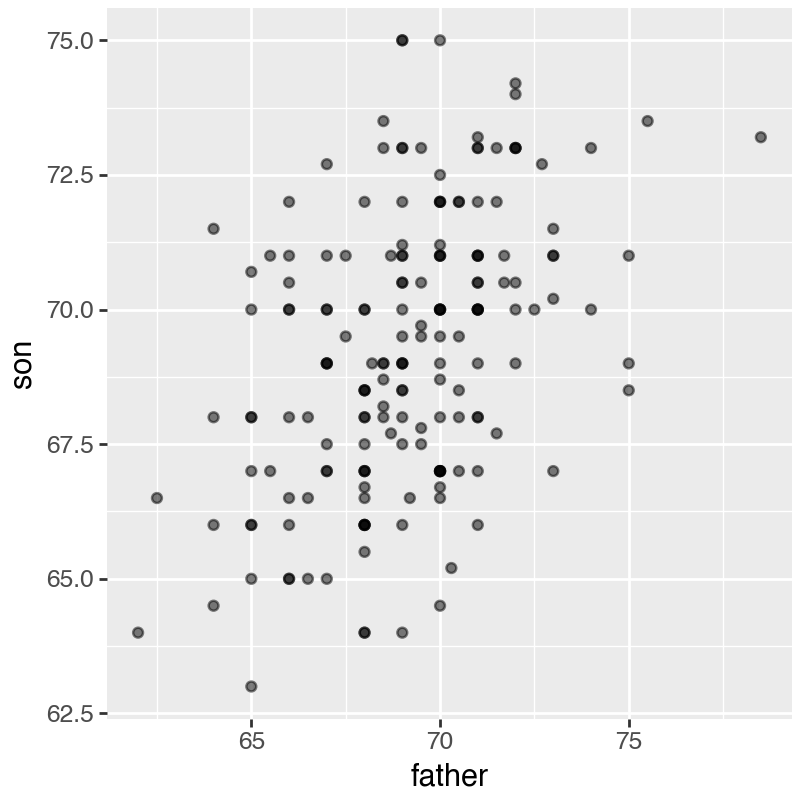

In [4]:
from plotnine import *

(
    ggplot(galton_heights, aes(x = 'father', y = 'son')) + 
    geom_point(alpha = 0.5) +
    theme(figure_size= (4,4))
)

One can visualize more concretely the conditional distributions of the son heights given the father heights by stratifying the father heights 

i.e. 
$p(\text{son}|\text{father})$ 

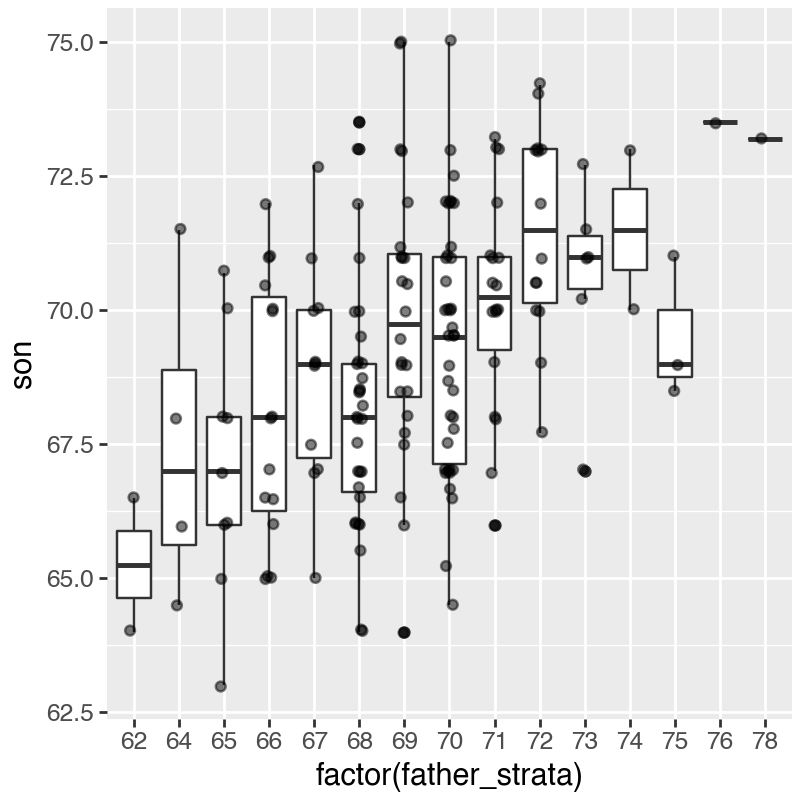

In [5]:
galton_heights['father_strata'] = (
    galton_heights['father']
    .round()
    .astype(int)
    # .astype('category') # this also solves the issue instead of using factor(father_strata) in ggplot
)

(
    ggplot(galton_heights, aes(x = 'factor(father_strata)', y = 'son')) +
    geom_boxplot() + 
    geom_jitter(color='black', alpha=0.5, width=0.1) + 
    theme(figure_size= (4,4))
)

The medians of the groups are increasing with the father height, giving a first glimpse as how hereditary body height is.

By strata, we can estimate the conditional expectations. In our example, we end up with the following prediction for the son of a father who is 72 inches tall:

In [6]:
conditional_avg = (
    galton_heights[
        galton_heights['father'].round() == 72
    ]['son']
    .mean() # np.float64(71.05)
    .item() # 71.05
)

conditional_avg

71.49285714285715

Furthermore, these centers appear to follow a linear relationship. Below we plot the averages of each group. If we take into account that these averages are random variables, the data is consistent with these points following a straight line:

In [7]:
means = galton_heights.copy()

means['father'] = means['father'].round()

son_conditional_avg = means.groupby('father', as_index= False)['son'].mean()
# if as_index wasn't used, then the father heihgt would be the index !

son_conditional_avg.head()

,father,son
0,62.0,65.250000
1,64.0,67.500000
2,65.0,67.077778
3,66.0,68.100000
4,67.0,68.836364


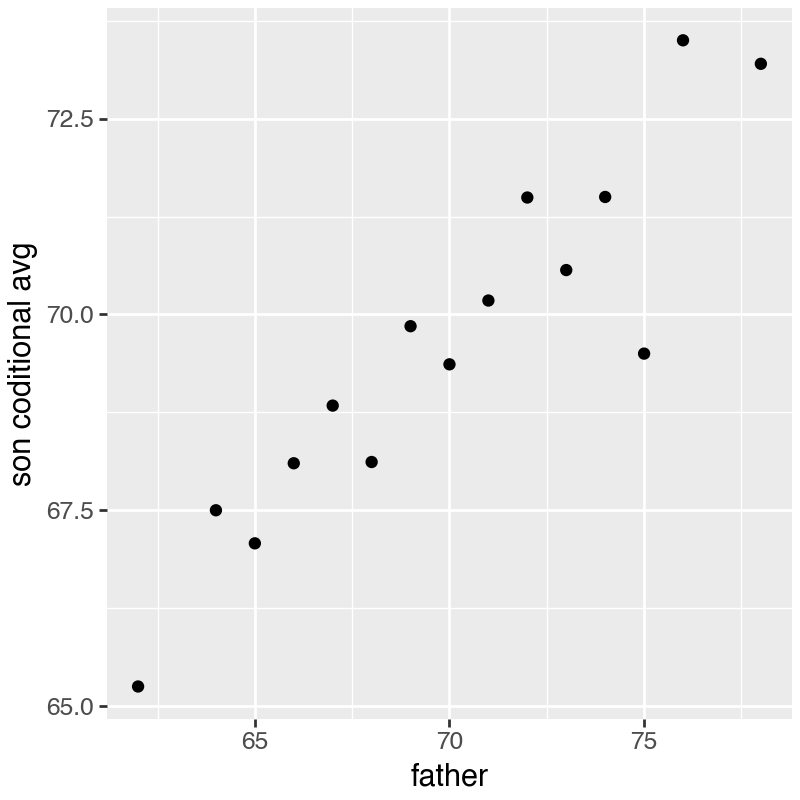

In [8]:
(
    ggplot(son_conditional_avg, aes(x = 'father', y = 'son')) +
    geom_point() + 
    theme(figure_size= (4,4)) +
    labs(y = 'son coditional avg')
)

Hence this plot suggests that the linear model:

$E[\text{son}|\text{father}] = \beta_0 + \beta_1 * \text{father}$

is reasonable. Fitting such a model would allow us to avoid doing stratifications, as we could continuously estimate the expected value of son’s height. How do we estimate these coefficients? To this end, we need a bit more theory.

-----
### Maximum Likelihood and Least Squares Estimates

Fitting a linear regression, i.e. estimating the parameters, is based on a widely used principle called <u>maximum likelihood</u>. 

The maximum likelihood principle consists in choosing as parameter values those for which the data is most probable. What is the probability of our data?

Here we model the probability of the heights of the sons given the heights of their fathers. 

Generally, we will always consider the values of the explanatory variables to be given. 

Furthermore we will assume that, conditioned on the values of the explanatory variable, the observations are independent. Here, this means that the height of the sons are independent given the heights of the fathers. Hence the likelihood is:

<u>NOT -></u>  “All sons are independent given the same father’s height”

<u>TRUE -> </u> Each son has his own father, and given each father’s height, the sons’ heights do not influence each other.

$p(\text{Data}| \beta_0, \beta_1) = \prod_i p(y_i | x_i, \beta_0, \beta_1)$ 

Hence, we look for the values of the coefficients $\beta_0$
 and $\beta_1$
 to maximimize $\prod_i p(y_i | x_i, \beta_0, \beta_1)$

Taking the logarithm of the likelihood, which is a monotonically increasing function, does not change the value of the optimal parameters. 

Plugging in furthermore the density of the Gaussian and discarding terms not affected by the values of $\beta_0, \beta_1$ 
, we obtain that:


$$\underset{\beta_0, \beta_1}{\operatorname{arg max}}\quad\underset{i}{\prod}p(y_i|x_i,\beta_0, \beta_1)$$


$$= \underset{\beta_0, \beta_1}{\operatorname{arg max}}\quad\underset{i}{\sum}\log \mathcal{N}(y_i|x_i,\beta_0, \beta_1)$$


$$= \underset{\beta_0, \beta_1}{\operatorname{arg min}}\quad\underset{i}{\sum}(y_i - (\beta_0 + \beta_1 * x_i))^2$$


We assumed each $y_i$ is normally distributed given $x_i$, with mean $\mu_i = \beta_0 + \beta_1 * x_i$ and variance $\sigma^2$ (assumed fixed)

So

$y_i | x_i \sim \mathcal{N}(\beta_0 + \beta_1 * x_i , \sigma^2) $

$\mathcal N(y_i \mid \mu_i,\sigma^2) =\frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left( -\frac{(y_i-\mu_i)^2}{2\sigma^2}\right)$

Take the log 

$\log \mathcal N(y_i \mid \mu_i,\sigma^2) = -\frac{1}{2}\log(2\pi\sigma^2) -\frac{(y_i-\mu_i)^2}{2\sigma^2} $

Sum over

$\sum_i \log \mathcal N(y_i \mid \mu_i,\sigma^2) = -\frac{n}{2}\log(2\pi\sigma^2) -\frac{1}{2\sigma^2}\sum_i (y_i-\mu_i)^2$

Now substitute $\mu_i = \beta_0 + \beta_1 x_i$


$= -\frac{n}{2}\log(2\pi\sigma^2) -\frac{1}{2\sigma^2} \sum_i (y_i-(\beta_0+\beta_1 x_i))^2$

When maximizing over $\beta_0,\beta_1$ is equivalent to <u>minimizing</u>: 

$\sum_i (y_i-(\beta_0+\beta_1 * x_i))^2$

The differences between the observed values and their expected values denoted 
are called the errors.

Hence, maximizing the likelihood of this model is equivalent to minimizing the sum of the squared errors. 

One talks about <u>least squares estimates (LSE)</u>.

<img src = 'images/Linear Regression Data Analysis.png' width = 600>

-----
### Interpretation of The Fitted Coefficients

Minimizing the squared errors for a linear model can be solved analytically. We obtain that our estimated conditional expected value, denoted $\hat{y}$ is:

$\hat{y} = \hat{\beta_0} + \hat{\beta_1} * x$ with slope $\hat{\beta_1} = \rho\frac{\sigma_y}{\sigma_x}$ and intercept $\hat{\beta_0} = \mu_y - \hat{\beta_1} * \mu_x$

For data set $(x,y)_i$ with $i \in \{1, ... N\}$ the univariate linear model is defined as

$y_i = \alpha + \beta x_i + \epsilon_i$

with free parameters $\alpha$ and $\beta$ and a random error $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$ that is i.i.d. (independently and identically distributed).

The normal distribution is defined as

$$\mathcal{N}(\epsilon|0, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \operatorname{exp}(-\frac{\epsilon^2}{2\sigma^2})$$

The assumption that the errors $\epsilon_i$ are independent and identically distributed allows us to factorize the Likelihood of the data under the linear model as

$$L(\alpha, \beta, \sigma^2) = \prod_{i=1}^{N} \mathcal{N}(\varepsilon_i \mid 0, \sigma^2)$$

using the fact that the probability of independent events is the product of the probabilities of each individual event.

We are interested in finding the parameters $\alpha$
, $\beta$
 and $\sigma^2$
 that best model our data. This can be achieved by finding the parameters that maximize the likelihood of our data. As maximizing the likelihood is equivalent to maximizing the log likelihood and as the log likelihood is easier to handle, we will use the log likelihood in the following.

The log likelihood of our data is defined as follows:

$$
\begin{aligned}
\log\bigl(L(\alpha,\beta,\sigma^2)\bigr)
&= \log\left(\prod_{i=1}^{N} \mathcal{N}(\varepsilon_i \mid 0, \sigma^2)\right) \\[6pt]
&= \sum_{i=1}^{N} \log\!\left(\mathcal{N}\bigl(y_i - (\alpha + \beta x_i) \mid 0, \sigma^2\bigr)\right) \\[6pt]
&= -\frac{N}{2}\log(2\pi\sigma^2)
\;-\;
\sum_{i=1}^{N} \frac{\bigl(y_i - (\alpha + \beta x_i)\bigr)^2}{2\sigma^2}.
\end{aligned}
$$

We can maximize a quadratic function by computing its gradient and setting it to zero, this yields:


$$
\begin{aligned}
&\textbf{Model:}\quad y_i=\alpha+\beta x_i+\varepsilon_i,\qquad \varepsilon_i\sim \mathcal N(0,\sigma^2).\\[4pt]
&\textbf{Negative log-likelihood (up to constants):}\quad
Q(\alpha,\beta,\sigma^2)
=\frac{N}{2}\log(\sigma^2)+\frac{1}{2\sigma^2}\sum_{i=1}^N\bigl(y_i-\alpha-\beta x_i\bigr)^2.\\[6pt]
&\textbf{Step 1: minimize w.r.t. }\alpha,\beta\textbf{ for fixed }\sigma^2.\\
&\text{Equivalently minimize }S(\alpha,\beta):=\sum_{i=1}^N\bigl(y_i-\alpha-\beta x_i\bigr)^2.\\[6pt]
&\textbf{Compute gradients:}\\
\frac{\partial S}{\partial \alpha}
&=\sum_{i=1}^N 2\bigl(y_i-\alpha-\beta x_i\bigr)(-1)
=-2\sum_{i=1}^N\bigl(y_i-\alpha-\beta x_i\bigr),\\[4pt]
\frac{\partial S}{\partial \beta}
&=\sum_{i=1}^N 2\bigl(y_i-\alpha-\beta x_i\bigr)(-x_i)
=-2\sum_{i=1}^N x_i\bigl(y_i-\alpha-\beta x_i\bigr).\\[6pt]
&\textbf{Set the gradient to zero (normal equations):}\\
0&=\sum_{i=1}^N\bigl(y_i-\alpha-\beta x_i\bigr)
=\sum_{i=1}^N y_i-N\alpha-\beta\sum_{i=1}^N x_i,\\[4pt]
0&=\sum_{i=1}^N x_i\bigl(y_i-\alpha-\beta x_i\bigr)
=\sum_{i=1}^N x_i y_i-\alpha\sum_{i=1}^N x_i-\beta\sum_{i=1}^N x_i^2.\\[6pt]
&\textbf{Let }\bar x=\frac{1}{N}\sum_{i=1}^N x_i,\qquad \bar y=\frac{1}{N}\sum_{i=1}^N y_i.\\
&\text{From the first equation:}\quad \hat\alpha=\bar y-\hat\beta\,\bar x.\\[6pt]
&\text{Substitute into the second and simplify to get:}\\
\hat\beta
&=\frac{\sum_{i=1}^N (x_i-\bar x)(y_i-\bar y)}{\sum_{i=1}^N (x_i-\bar x)^2}.\\[8pt]
&\textbf{Step 2: minimize w.r.t. }\sigma^2.\\
&\frac{\partial Q}{\partial \sigma^2}
=\frac{N}{2}\frac{1}{\sigma^2}-\frac{1}{2(\sigma^2)^2}\sum_{i=1}^N\bigl(y_i-\hat\alpha-\hat\beta x_i\bigr)^2=0\\
&\Longrightarrow\quad
\hat\sigma^2=\frac{1}{N}\sum_{i=1}^N\bigl(y_i-(\hat\alpha+\hat\beta x_i)\bigr)^2.
\end{aligned}
$$

$$
\begin{aligned}
0
&= \sum_{i=1}^N x_i y_i - \alpha \sum_{i=1}^N x_i - \beta \sum_{i=1}^N x_i^2 \\[6pt]
&\text{Substitute } \alpha = \bar y - \beta \bar x: \\[6pt]
0
&= \sum_{i=1}^N x_i y_i
- (\bar y - \beta \bar x)\sum_{i=1}^N x_i
- \beta \sum_{i=1}^N x_i^2 \\[6pt]
&= \sum_{i=1}^N x_i y_i
- \bar y \sum_{i=1}^N x_i
+ \beta \bar x \sum_{i=1}^N x_i
- \beta \sum_{i=1}^N x_i^2 \\[6pt]
&\text{Use } \sum_{i=1}^N x_i = N\bar x: \\[6pt]
0
&= \sum_{i=1}^N x_i y_i
- N\bar x \bar y
- \beta\bigl(\sum_{i=1}^N x_i^2 - N\bar x^2\bigr) \\[6pt]
\Longrightarrow\quad
\beta
&= \frac{\sum_{i=1}^N x_i y_i - N\bar x \bar y}
{\sum_{i=1}^N x_i^2 - N\bar x^2} \\[8pt]
&= \frac{\sum_{i=1}^N (x_i-\bar x)(y_i-\bar y)}
{\sum_{i=1}^N (x_i-\bar x)^2}.
\end{aligned}
$$

$$
\begin{aligned}
\sum_{i=1}^N (x_i-\bar x)(y_i-\bar y)
&= \sum_{i=1}^N \bigl(x_i y_i - x_i\bar y - \bar x y_i + \bar x\bar y\bigr) \\[6pt]
&= \sum_{i=1}^N x_i y_i
- \bar y \sum_{i=1}^N x_i
- \bar x \sum_{i=1}^N y_i
+ \sum_{i=1}^N \bar x\bar y \\[6pt]
&= \sum_{i=1}^N x_i y_i
- \bar y (N\bar x)
- \bar x (N\bar y)
+ N\bar x\bar y \\[6pt]
&= \sum_{i=1}^N x_i y_i - N\bar x\bar y.
\end{aligned}
$$

$$
\begin{aligned}
\sum_{i=1}^N (x_i-\bar x)^2
&= \sum_{i=1}^N (x_i^2 - 2x_i\bar x + \bar x^2) \\[6pt]
&= \sum_{i=1}^N x_i^2
- 2\bar x \sum_{i=1}^N x_i
+ \sum_{i=1}^N \bar x^2 \\[6pt]
&= \sum_{i=1}^N x_i^2
- 2N\bar x^2
+ N\bar x^2 \\[6pt]
&= \sum_{i=1}^N x_i^2 - N\bar x^2.
\end{aligned}
$$

After the derivations again we can look up the equation

$\hat{y} = \hat{\beta_0} + \hat{\beta_1} * x$ with slope $\hat{\beta_1} = \rho\frac{\sigma_y}{\sigma_x}$ and intercept $\hat{\beta_0} = \mu_y - \hat{\beta_1} * \mu_x$

where

* $\mu_x, \mu_y$ are the means of $x$ and $y$
* $\sigma_x, \sigma_y$ are the standard deviations of $x$ and $y$
* $\rho = \frac{1}{n}\sum_{i=1}^n(\frac{x_i-\mu_x}{\sigma_x})(\frac{y_i-\mu_y}{\sigma_y})$  is the Pearson correlation coefficient between $x$
 and $y$
.

We can rewrite this result as:

$$
\hat{y} = \mu_y + \rho(\frac{x-\mu_x}{\sigma_x})\sigma_y
$$

If there is perfect correlation, the regression line predicts an increase in the response by the same number of standard deviations. If there is 0 correlation, then we don’t use $x$
 at all for the prediction and simply predict the population average $\mu_y$
. For values between 0 and 1, the prediction is somewhere in between. If the correlation is negative, we predict a reduction instead of an increase. Note that if the correlation is positive but smaller than 1, our prediction of $y$
 is closer to its average than $x$
 to its average (in standard units).

In Python, we can obtain the least squares estimates using the `smf.ols` function:

In [9]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
np.random.seed(1983)

In [10]:
model = smf.ols('son ~ father', data=galton_heights).fit()
model.params

Intercept    38.651452
father        0.442552
dtype: float64

The most common way we use `smf.ols` is by using the character `~` to let `smf.ols` know which is the variable we are predicting `(left of ~)` and which we are using to predict `(right of ~)`. 

The intercept is added automatically to the model that will be fit.

Here we add the regression line using `geom_smooth(method="lm")`, which in Python (plotnine) computes and adds a linear regression line to a plot along with confidence intervals:

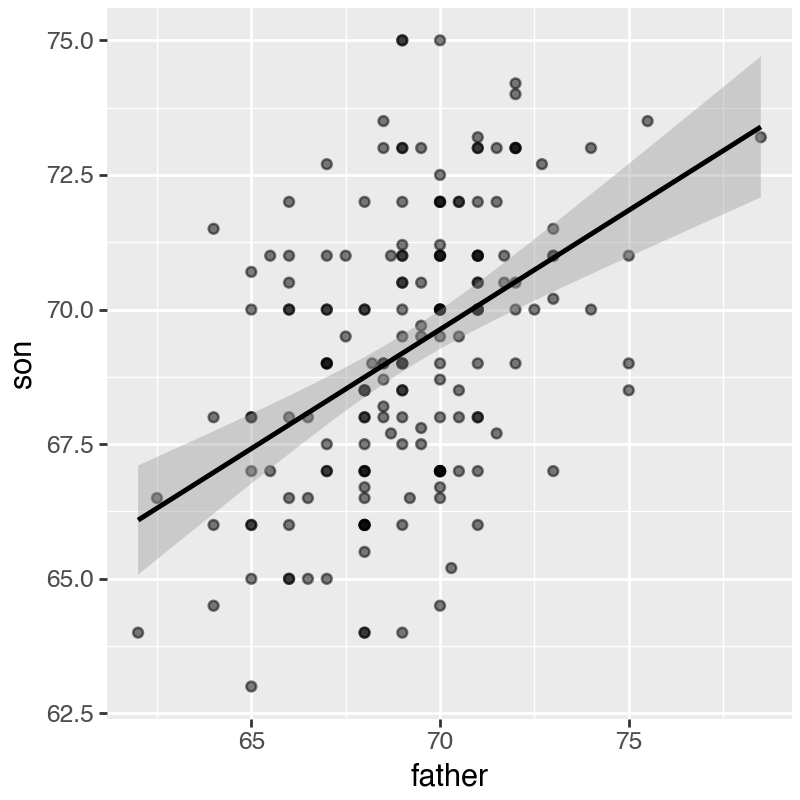

In [11]:
(
    ggplot(galton_heights, aes('father', 'son')) + 
    geom_point(alpha = 0.5) + 
    geom_smooth(method = 'lm') +
    theme(figure_size= (4,4))
)


In our example, the correlation between sons’ and fathers’ heights is about $0.5$. Our predicted value for the son’s height 
$y=$ 71.49 for a 72-inch father was only 0.88 standard deviations larger than the average son, in contrast to the father’s height, which was 1.14 standard deviations above average.

This is why we call it regression: the son regresses to the average height. In fact, the title of Galton’s paper was: Regression toward mediocrity in hereditary stature.

It is a fact that children of extremely tall parents are taller than average, yet typically shorter than their parents. You can appreciate it on below graph. Extremely tall parents have an extreme combinations of alleles, and have also benefited from environmental factors by chance, which may not repeat in the next generation. The same phenomenon, called regression toward the mean, happens in sport. Athletes who perform extremely well one year are certainly good (high expectation) but have also probably been lucky (a positive error) so they are more likely to perform relatively worse the next year, etc. This phenomenon is ubiquitous and can lead to fallacies.6

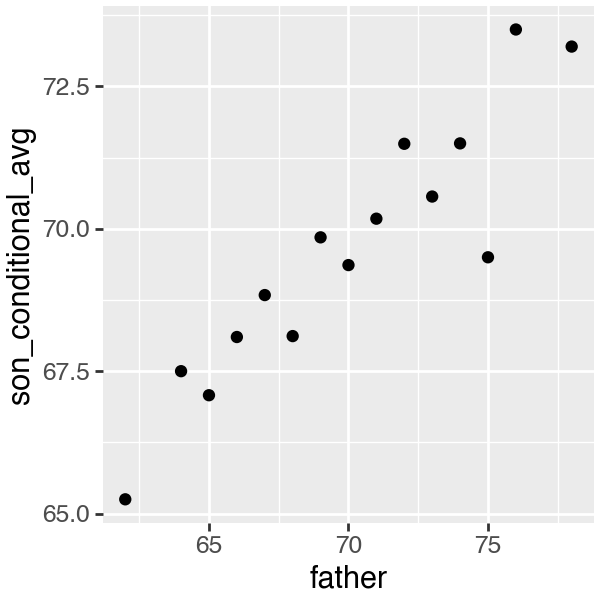

In [12]:
(
  ggplot(son_conditional_avg, aes('father', 'son'))
  + geom_point()
  + labs(x='father', y='son_conditional_avg')
  + theme(figure_size=(3, 3))
)

### Predicted Values Are Random Variables

Once we fit our model, we can obtain predictions of $y$
 by plugging the estimates into the regression model.
 
 For example, if the father’s height is $x$
, then our prediction $\hat{y}$
 for the son’s height is:

$$
\hat{y} = \hat\beta_0 + \hat\beta_1 x
$$

when we plot $\hat y$ versus $x$, we see the regression line

Keep in mind that the prediction $\hat y$ is also a random variable.

The standard errors can be derived analytically. If we assume the errors are normal, or we have a large enough sample size, we can use theory to construct confidence intervals as well. 

In fact, the ggplot layer `geom_smooth(method = "lm")` that we previously used plots 
and surrounds it by confidence intervals:

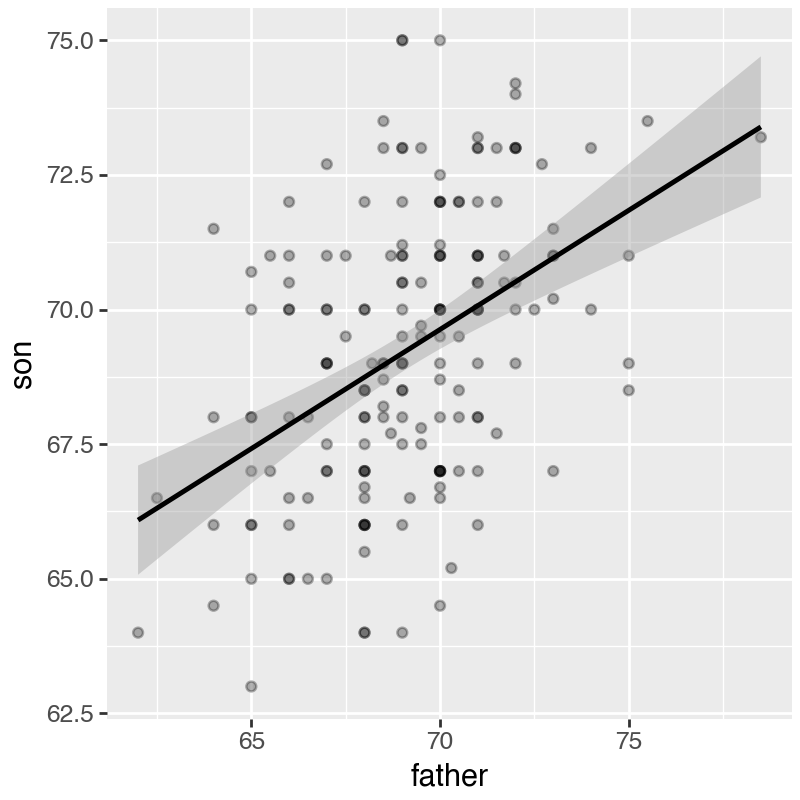

In [13]:
(
    ggplot(galton_heights, aes('father', 'son')) +
    geom_point(alpha = 0.3) + 
    geom_smooth(method = 'lm') +
    theme(figure_size= (4,4))
)

The Python method `get_prediction` of an `smf.ols` object takes the data as input and returns the prediction.

If requested, the standard errors and other information from which we can construct confidence intervals are provided:

In [14]:
y_hat = model.get_prediction(galton_heights)
y_hat.summary_frame().columns

Index(['mean', 'mean_se', 'mean_ci_lower', 'mean_ci_upper', 'obs_ci_lower',
       'obs_ci_upper'],
      dtype='object')

------

### Explained Variance

Any dataset will give us estimates of the model, but how well does the model represent our data? 

To investigate this we can compute quality metrics and visually assess the model, which is explained later.

Under the linear regression assumptions, the conditional standard deviation is:

$$
SD(y|x) = \sigma_y \sqrt{1-\rho^2}
$$

To see why this is intuitive, notice that without conditioning,

$SD(y) = \sigma_y$, we are looking at the variability of all the sons. 

But once we condition, we are only looking at the variability of the sons with the same father’s height (for instance all those with a 72-inch, father). 

This group will tend to have similar heights so the standard deviation is reduced.

This is usually quantified in terms of proportion of variance. So we say that $X$
 explains 
$$
1- (1-\rho^2)
$$
 (the Pearson correlation squared) of the variance. The proportion of variance explained by the model is commonly called the <u>coefficient of determination</u> or $R^2$
. Another way of deriving $R^2$
 is described in the following steps:

First, we compute the model predictions:

$$
\hat y_i = \hat\beta_0 + \hat\beta_1 x_i
$$

Then, we compute the residuals (by comparing the predictions with the actual values):

$$
\hat\epsilon = y_i - \hat y_i
$$

and the residual sum of <b>squares</b>

$$
RSS = \sum^N_{i=1}\hat\epsilon_i^2
$$

Lastly, we can compare the residual sum of squares to the total sum of squares (SS) of $y$

$$
R^2 = 1 - \frac{\sum^N_{i=1}\hat\epsilon_i^2}{\sum^N_{i=1}(y_i - \bar y)^2} = 1 - \frac{RSS}{SS}
$$

It can take any value between 0 and 1, since the sum of squares represents the variation around the global mean and the residual sum of squares represents the variation around the model predictions. 

In case the model learned no variation, it learned at least the global mean. In this case the sum of squares and the residual sum of squares are equal and $R^2 = 0$

. In case the model is perfect, the residuals are zero and hence the second term vanishes and the $R^2$
 becomes 1.

The $R^2$
 is usually best combined with a scatter plot of $y$
 against $\hat y$
.

In [15]:
model = smf.ols('son ~ father', data = galton_heights).fit()
pred = model.get_prediction(galton_heights) # pred.predicted
r2 = model.rsquared # np.float64(0.19227660786209344)

df_pred = galton_heights.copy()
df_pred['pred'] = pred.predicted

df_pred.head()


,father,son,father_strata,pred
0,78.5,73.2,78,73.391766
4,75.5,73.5,76,72.064111
8,75.0,71.0,75,71.842835
11,75.0,68.5,75,71.842835
16,75.0,69.0,75,71.842835


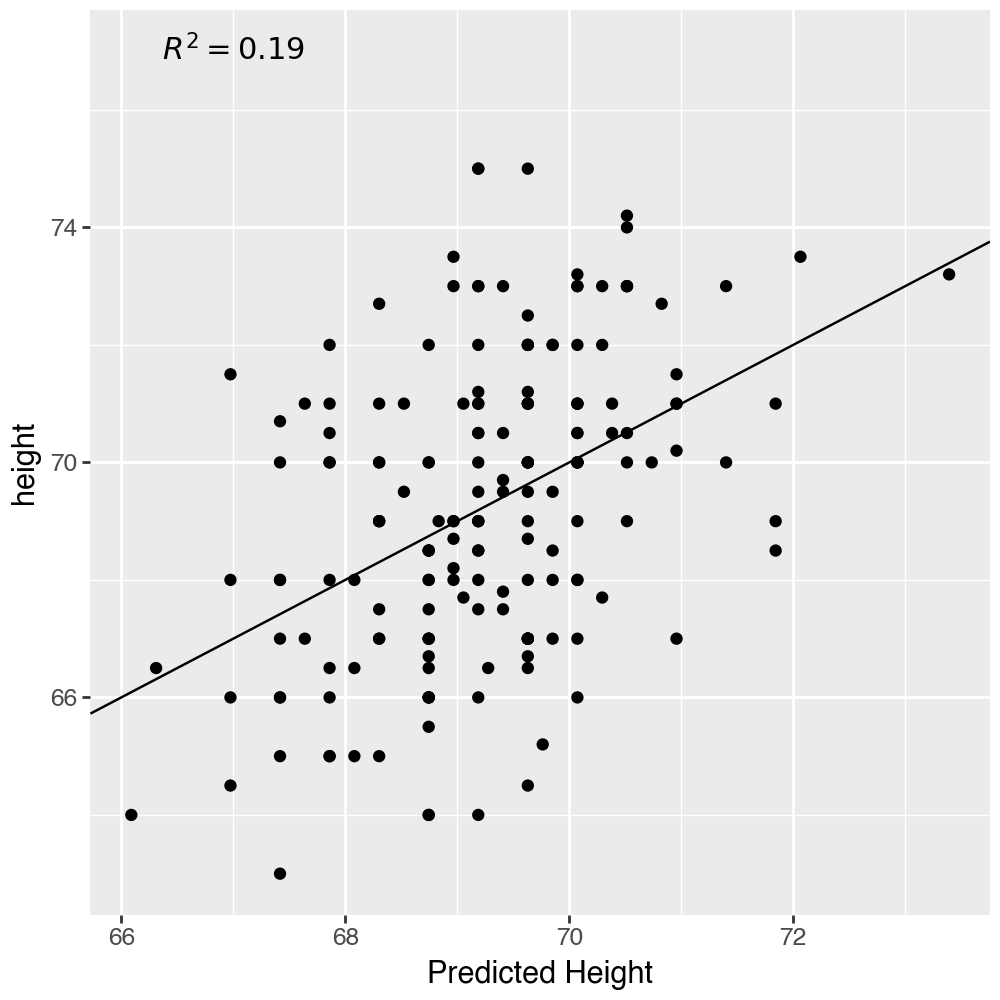

In [16]:
(
    ggplot(df_pred, aes('pred', 'son')) + 
    geom_point() + 
    geom_abline(intercept = 0, slope = 1) + 
    annotate(
        'text',
        x = 67,
        y = 77,
        label = rf'$R^2 = {r2:.2f}$'
    ) +
    labs(x = 'Predicted Height', y = 'height') +
    theme(figure_size= (5,5)) 
)

--------

### Testing Relationship Between X and Y

The LSE (least squares estimates) is derived from the data $y_1, y_2, ..., y_n$, which are a realization of random variables. 

This implies that our estimates are random variables. Using the assumption of independent Gaussian noise, we obtain the following distribution:

$$
p(\hat\beta) = \mathcal{N}(\beta, \frac{\sigma^2}{ns_x^2})
$$

Hence, if the modeling assumptions hold, the estimates are unbiased, meaning that their expected value are the true values of the parameter 
$$
E[\hat\beta] = \beta_1
$$

Moreover they are consistent, meaning that for infinitely large sample size they converge to the true values.

Another result allows us to build a hypothesis test for any given null-hypothesis values of $\hat\beta_1$
, namely

$$
p(\frac{\hat\beta_1 - \beta_1}{\hat{\text{se}}(\hat\beta_1)}) = t_{n-2}(\frac{\hat\beta_1 - \beta_1}{\hat{\text{se}}(\hat\beta_1)})
$$

where $t_{n-2}$
 denotes the student’s $t$
 distribution with $n-2$
 degrees of freedom and

$$
\hat{\text{se}}(\hat\beta_1) = \sqrt{\frac{1}{n-2} \frac{\sum_i (y_i - \bar y_i)^2}{\sum_i (x_i - \bar x_i)^2}}
$$

As for the t-test presented for comparing two groups in Section Section 8.4.1.1,

the degrees of freedom is equal to the number of data points $n$
 minus two, the number of model parameters ( $\beta_0$
 and $\beta_1$
).

Remember, the $P$-
value of a statistical test is the probability of the value of a test statistic being at least as extreme as the one observed in our data under the null hypothesis.

In our case we can formulate the null hypothesis, that $y$
 does not depend on $x$
 as follows:

* The null hypothesis for parameter $\beta_1$ is $H_0 : \beta_1 = 0$: there is no linear association between $x$ and $y$

* Reject $H_0$: we conclude that there is a statistically significant linear association between $y$ and $x$

* Do not reject $H_0$: the data do not provide sufficient evidence of a statistically significant linear association between $y$ and $x$

* The test statistic is $\hat t = \frac{\hat\beta_1 - \beta_1}{\hat{\text{se}}(\hat\beta_1)}$ 

* The probability under the null model is $P(t \geq \hat t)$, where $t \sim t_{n-2}$

How do we do this in Python? 

The `summary2().tables[1].` function helps us here.

It reports t-statistics (t value) and two-sided $P$-values under $Pr(>|t|)$. Indeed, $P(|t| \geq |\hat t|)$ yields the two-sided p-value because the Student’s t-distribution is symmetric.

In [18]:
model.summary2().tables[1]

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,38.651452,4.714218,8.198911,4.763915e-14,29.348145,47.954760
father,0.442552,0.068178,6.491103,8.288243e-10,0.308005,0.577099


---------

## Multivariate Regression

Since Galton’s original development, regression has become one of the most widely used tools in data science. One reason for this has to do with the fact that regression permits us to find relationships between two variables taking into account the effects of other variables. This has been particularly popular in fields where randomized experiments are hard to run, such as economics and epidemiology.

When we are not able to randomly assign each individual to a treatment or control group, confounding is particularly prevalent. 

For example, consider estimating the effect of eating fast foods on life expectancy using data collected from a random sample of people in a jurisdiction. Fast food consumers are more likely to be smokers, drinkers, and have lower incomes. Therefore, a naive regression model may lead to an overestimate of the negative health effect of fast food. So how do we account for confounding in practice? In this section we learn how linear regression against multiple variables, or multivariate regression, can help with such situations and can be used to describe how one or more variables affect an outcome variable.

### The Baseball Dataset

We will use data from baseball, leveraging a famous real application of regression which has led to improved estimations of baseball player values in the 90’s. Here we will not build a model of player value but, instead, we will focus on predicting the game scores of a team.

#### Baseball Basics

* The goal of a baseball game is to score more runs (points) than the other team. Each team has 9 batters that have an opportunity to hit a ball with a bat in a predetermined order. After the 9th batter, the first batter bats again, then the second, and so on.

* Each time a batter has an opportunity to bat, the other team’s pitcher throws the ball and the batter tries to hit it. The batter either makes an out and returns to the bench or the batter hits it.

* When the batter hits the ball, the batter wants to pass as many bases as possible before the opponent team catches the ball. There are four bases with the fourth one called home plate. Home plate is where batters start by trying to hit, so the bases form a cycle.

<img src = 'images/Linear Regression Visualization.png' widht = 600>

* A batter who stops at one of the intermediate three bases can resume running along the base cycle when next batters hit the ball. A batter who goes around the bases and arrives home (directly or indirectly with stops at intermediate bases), scores a run.



We want to understand what makes a team score well on average. Hence, the average number of runs is our response variable.

#### Home Runs

A home run happens when the batter who hits the ball goes all the way home (https://www.youtube.com/watch?v=AJ7kLlwKDJI&t=35s). This happens when the ball is hit very far, giving time for the batter to perform the full run. It is very good for the score because not only the batter scores a run, but the other players of the same team who are already on the pitch standing at intermediate bases typically finish their runs too.

Not surprisingly, average home runs positively correlate with average runs:

In [22]:
teams = sm.datasets.get_rdataset("Teams", "Lahman").data
teams.head()

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,1884,UA,ALT,ALT,NaN,10,25,NaN,6,19,...,4,0.862,Altoona Mountain City,NaN,NaN,101,109,ALT,ALT,ALT
1,1961,AL,LAA,ANA,NaN,8,162,82.0,70,91,...,154,0.969,Los Angeles Angels,Wrigley Field (LA),603510.0,111,112,LAA,LAA,LAA
2,1962,AL,LAA,ANA,NaN,3,162,81.0,86,76,...,153,0.972,Los Angeles Angels,Dodger Stadium,1144063.0,97,97,LAA,LAA,LAA
3,1963,AL,LAA,ANA,NaN,9,161,81.0,70,91,...,155,0.974,Los Angeles Angels,Dodger Stadium,821015.0,94,94,LAA,LAA,LAA
4,1964,AL,LAA,ANA,NaN,5,162,81.0,82,80,...,168,0.978,Los Angeles Angels,Dodger Stadium,760439.0,90,90,LAA,LAA,LAA


In [24]:
teams_filtered = teams[teams.yearID.isin(range(1961,2001))]
teams_filtered['HR_per_game'] = teams_filtered['HR'] / teams_filtered['G']
teams_filtered['R_per_game']  = teams_filtered['R'] / teams_filtered['G']

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_16877/2287895327.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_16877/2287895327.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


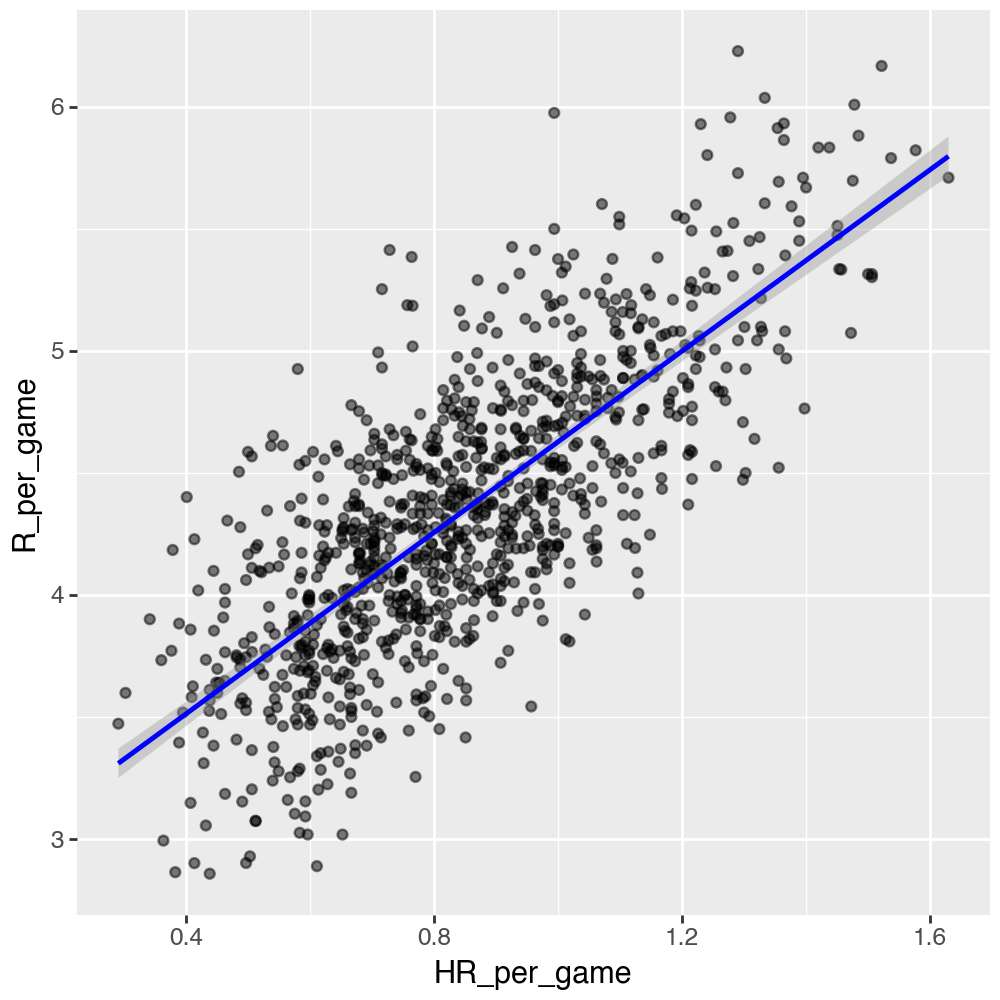

In [29]:
(
    ggplot(teams_filtered, aes('HR_per_game', 'R_per_game')) +
    geom_point(alpha = 0.5) + 
    geom_smooth(method = 'lm', color = 'blue') +
    theme(figure_size= (5,5))
)

A univariate linear regression gives the following parameter estimates:

In [31]:
fitted_model = smf.ols('R_per_game ~ HR_per_game', data = teams_filtered).fit()
print(fitted_model.params)

Intercept      2.769471
HR_per_game    1.858152
dtype: float64


So this tells us that teams that hit 1 more HR per game than the average team, score 1.858 more runs per game than the average team. 

Given that the most common final score is a difference of a run, this can certainly lead to a large increase in wins. Not surprisingly, HR hitters are very expensive. Because we are working on a budget, we will need to find some other way to increase wins. So, in the next section, we move our attention to another possible predictive variable of runs.



--------

#### Base on balls

Obviously the pitcher is encouraged to throw the ball at the batter. This is achieved thanks to the so-called <u>base on balls</u> rule stating that if the pitcher fails to throw the ball through a predefined area considered to be hittable (the strikezone), the batter is permitted to go to the first base.

A base on ball is not as great as a home run but it makes the batter progress by one base so it should be rather beneficial for the score. Let us now scatter plot average runs against average base on balls:

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_16877/3843331114.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


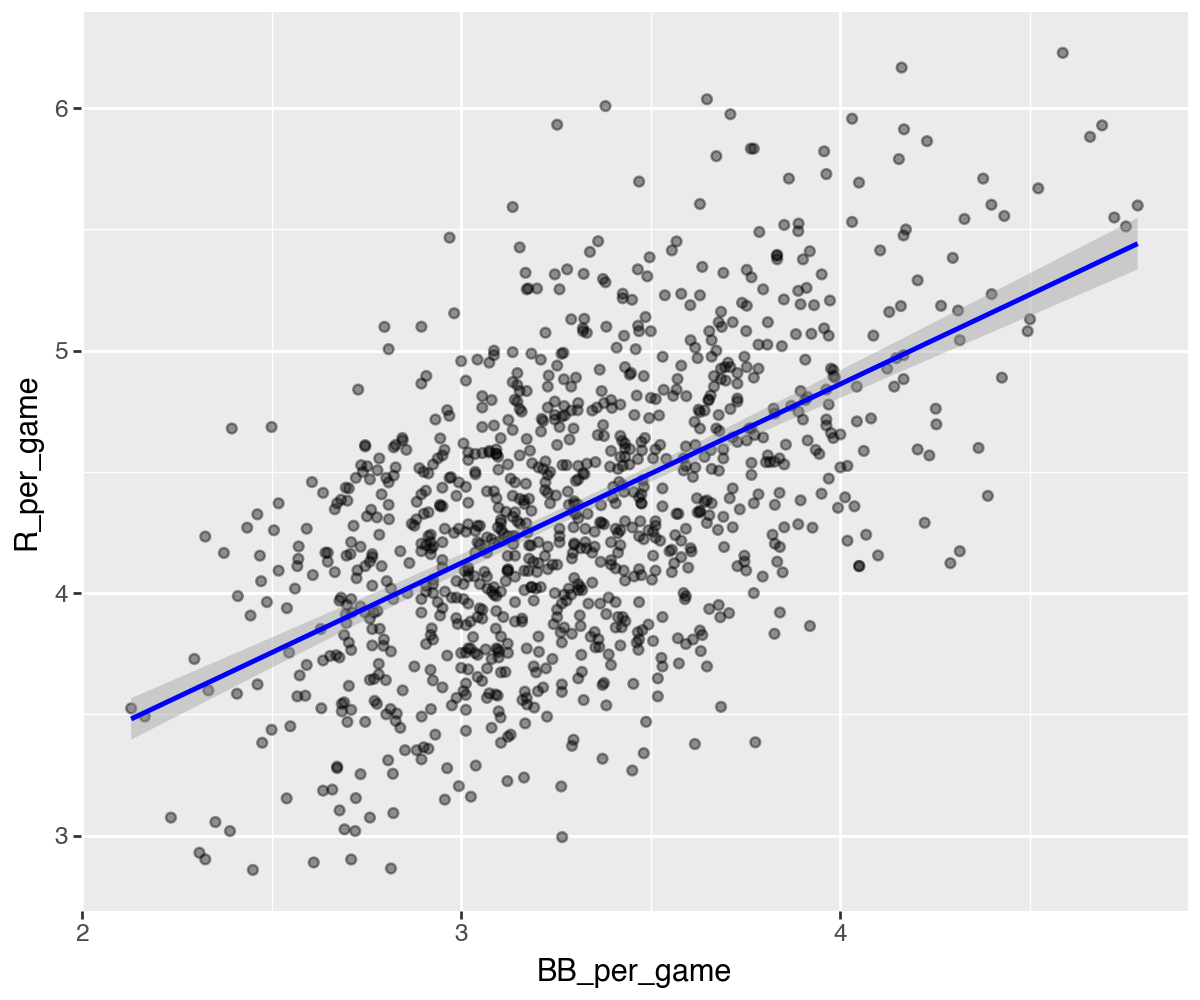

In [39]:
teams_filtered['BB_per_game'] = teams_filtered['BB'] / teams_filtered['G']

(
    ggplot(teams_filtered, aes('BB_per_game', 'R_per_game')) + 
    geom_point(alpha = 0.4) + 
    geom_smooth(method = 'lm', color = 'blue') +
    theme(figure_size= (6,5))
)

Here, again we see a clear association. If we find the regression line for predicting runs from bases on balls, we a get slope of:

In [46]:
def get_slope(x,y):
    return x.corr(y) * (y.std() / x.std())

bb_slope = get_slope(teams_filtered['BB_per_game'], teams_filtered['R_per_game'])
bb_slope

np.float64(0.7386443662708065)

So does this mean that if we go and hire low salary players with many BB, and who therefore increase the number of walks per game by 2, our team will score 1.4773 more runs per game?

In fact, it looks like BBs and HRs are also associated:

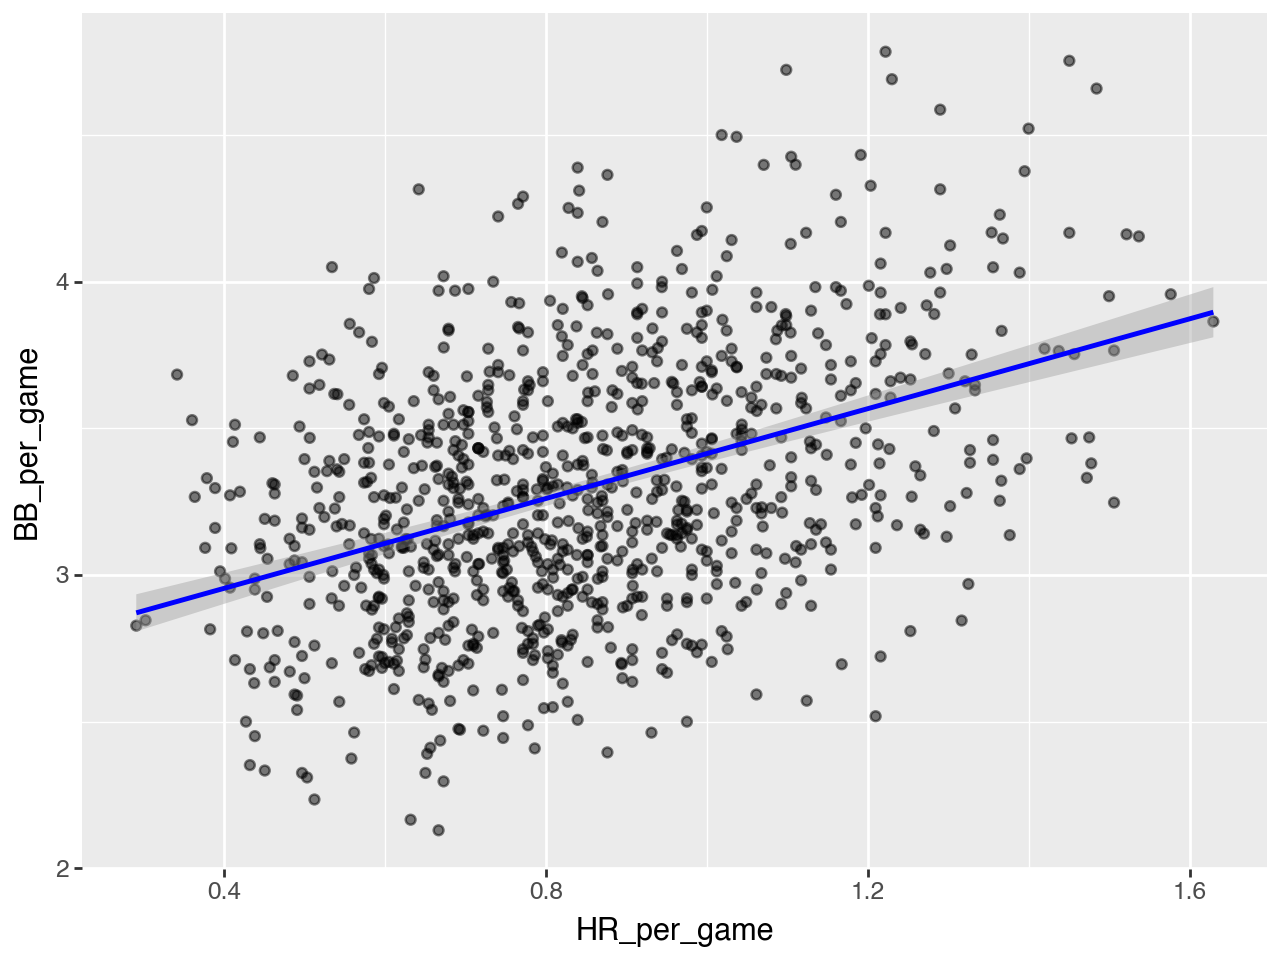

In [51]:
(
    ggplot(teams_filtered, aes('HR_per_game', 'BB_per_game')) +
    geom_point(alpha = 0.5) + 
    geom_smooth(method = 'lm', color = 'blue')
)

We know that HRs cause runs because, as the name “home run” implies, when a player hits a HR they are guaranteed at least one run. Could it be that HRs also cause BB and this makes it appear as if BB cause runs?



It turns out that pitchers, afraid of HRs, will sometimes avoid throwing strikes to HR hitters. 

As a result, HR hitters tend to have more BBs and a team with many HRs will also have more BBs. Although it may appear that BBs cause runs, it is actually the HRs that cause most of these runs. We say that BBs are confounded with HRs. 

Nonetheless, could it be that BBs still help? To find out, we somehow have to adjust for the HR effect. Linear regression will help us parse all this out and quantify the associations. This can in turn help determine what players to recruit.

-------
#### Understanding Confounding Through Stratification

We first untangle the direct from the indirect effects step-by-step by stratification to get a concrete understanding of the situation.

A first approach is to keep HRs fixed at a certain value and then examine the relationship between BB and runs. As we did when we stratified fathers by rounding to the closest inch, here we can stratify HR per game to the closest tenth. We filter out the strata with few points to avoid highly variable estimates:

and then make a scatterplot for each strata:

In [74]:
teams_filtered['HR_strata'] = teams_filtered['HR_per_game'].round(1)

teams_filtered['HR_strata'] = np.where((teams_filtered['HR_strata'] >= 0.4) & (teams_filtered['HR_strata'] <= 1.2), teams_filtered['HR_strata'], np.nan)

plot_df = teams_filtered.dropna(subset=['HR_strata'])

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_16877/382481483.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_16877/382481483.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


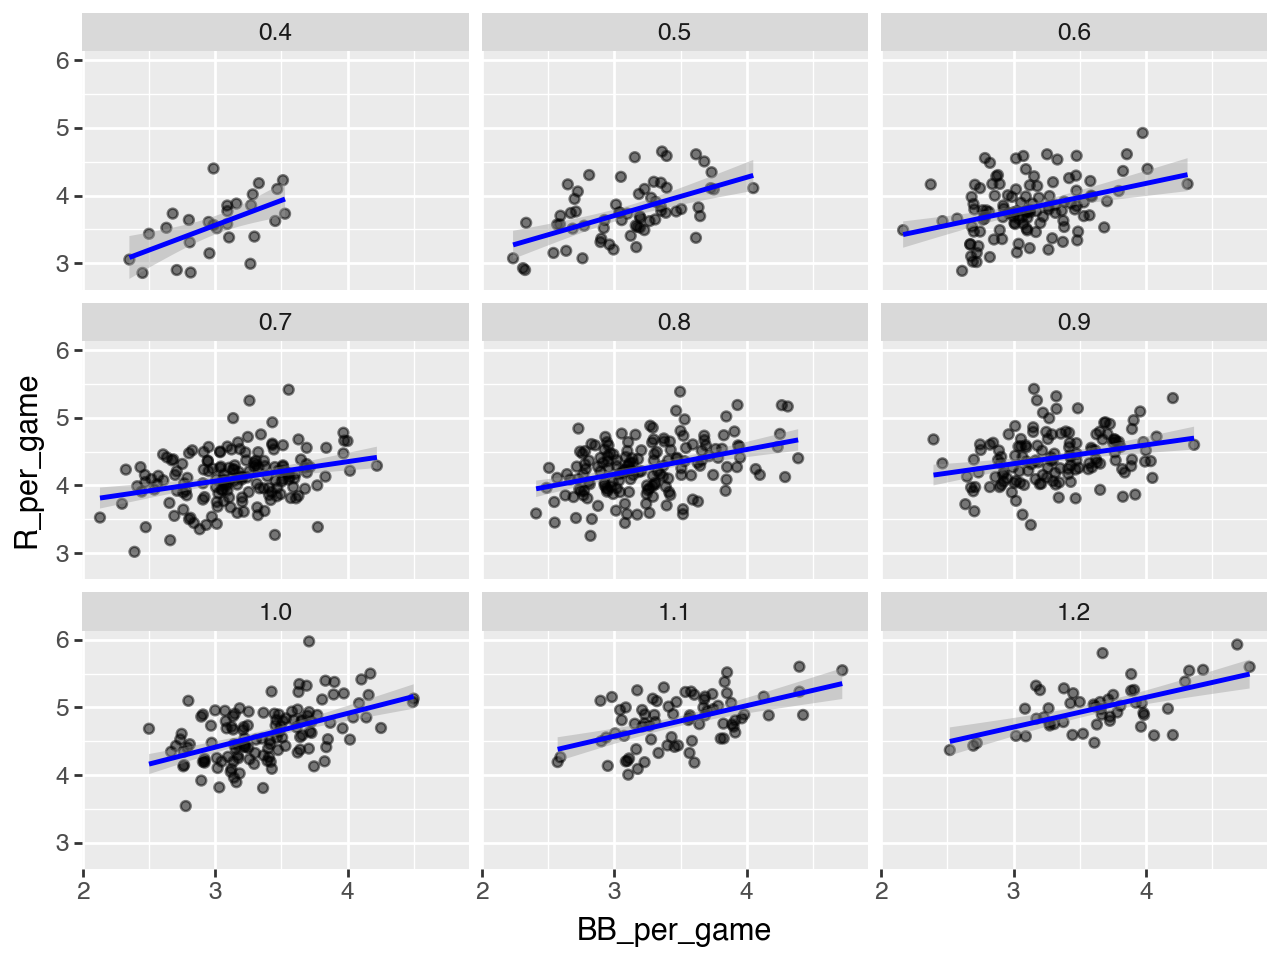

In [75]:
(
    ggplot(plot_df, aes('BB_per_game', 'R_per_game')) + 
    geom_point(alpha = 0.5) +
    geom_smooth(method = 'lm', color = 'blue') +
    facet_wrap('HR_strata')
)

Remember that the regression slope for predicting runs with BB was 0.7386. Once we stratify by HR, these slopes are substantially reduced:



In [80]:
(
    plot_df.groupby('HR_strata')
    .apply(lambda g: get_slope(g['BB_per_game'], g['R_per_game']))
    .reset_index(name = 'slope')
)

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_16877/2463563763.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,HR_strata,slope
0,0.4,0.734291
1,0.5,0.565907
2,0.6,0.411913
3,0.7,0.287261
4,0.8,0.364955
5,0.9,0.277184
6,1.0,0.499523
7,1.1,0.451475
8,1.2,0.439637


The slopes are reduced, but they are not 0, which indicates that BBs are helpful for producing runs, just not as much as previously thought

Although our understanding of the application tells us that HR cause BB but not the other way around, we can still check whether stratifying by BB makes the effect of HR go down. To do this, we use the same code except that we swap HR and BBs to get this plot:

In [81]:
teams_filtered['BB_strata'] = teams_filtered['BB_per_game'].round(1)
dat = teams_filtered[ (teams_filtered['BB_strata'] >= 2.8) & (teams_filtered['BB_strata'] <= 3.9)].copy()

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_16877/2924353273.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


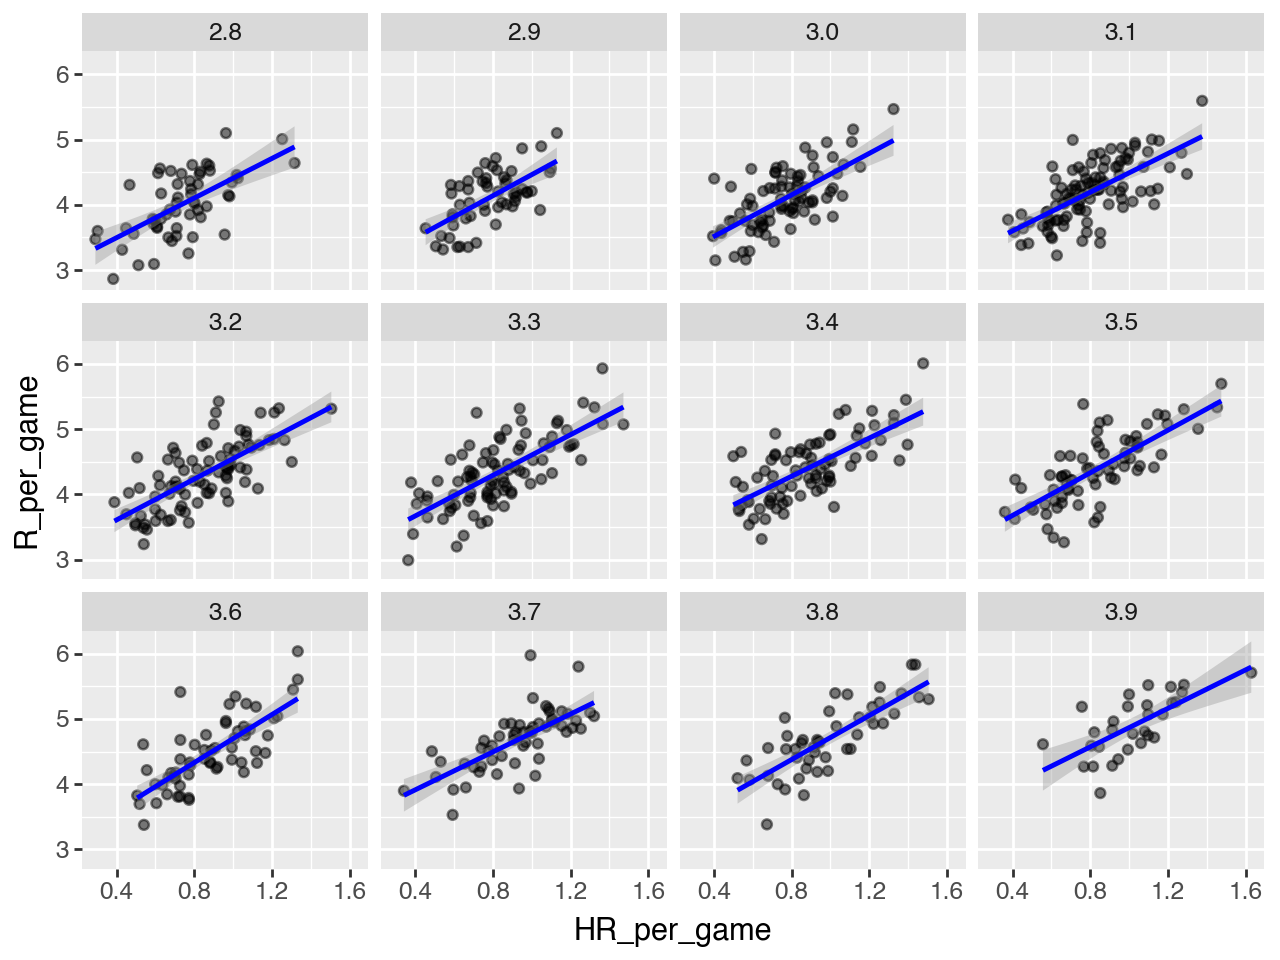

In [83]:
(
    ggplot(dat, aes('HR_per_game', 'R_per_game')) +
    geom_point(alpha = 0.5) + 
    geom_smooth(method = 'lm', color = 'blue') +
    facet_wrap('BB_strata')
)

In [84]:
(
    dat.groupby('BB_strata')
    .apply(lambda g : get_slope(g['HR_per_game'], g['R_per_game']))
    .reset_index(name = 'slope')
)

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_16877/653841129.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,BB_strata,slope
0,2.8,1.517439
1,2.9,1.614279
2,3.0,1.591178
3,3.1,1.481722
4,3.2,1.564997
5,3.3,1.555546
6,3.4,1.462050
7,3.5,1.631314
8,3.6,1.839057
9,3.7,1.451895


Compared the original:

In [85]:
hr_slope = get_slope(teams_filtered['HR_per_game'], teams_filtered['R_per_game'])
hr_slope

np.float64(1.858151991005777)

<u>Data suggests additive effects</u>

It is somewhat complex to be computing regression lines for each strata. We are essentially fitting models like this:

$$
\mathbb{E}[R \mid BB = x_1,\ HR = x_2]
= \beta_0 + \beta_1(x_2)\,x_1 + \beta_2(x_1)\,x_2
$$

with the slopes for $x_1$
 changing for different values of $x_2$
 and vice versa. But is there an easier approach?



If we take random variability into account, the slopes in the strata don’t appear to change much. If these slopes are in fact the same, this implies that $\beta_0(x_2)$
 and $\beta_1(x_0)$
 are constants. This in turn implies that the expectation of runs conditioned on HR and BB can be written like this:

$$
\mathbb{E}[R \mid BB = x_1,\ HR = x_2]
= \beta_0 + \beta_1x_1 + \beta_2x_2
$$

This model suggests that if the number of HR is fixed at $x_2$
, we observe a linear relationship between runs and BB with an intercept of $\beta_0 + \beta_1x_1$
. 

Our exploratory data analysis suggested this. The model also suggests that as the number of HR grows, the intercept growth is linear as well and determined by $\beta_1x_1$
.

In this analysis, referred to as multivariate regression, you will often hear people say that the BB slope $\beta_1$
 is adjusted for the HR effect. 
 
 If the model is correct then confounding has been accounted for. But how do we estimate  $\beta_1$
 and $\beta_2$
 from the data? For this, we need to derive some theoretical results that generalize the results from univariate linear regression.

------
## Fitting Multivariate Regression

For a data set $(x_i,y_i)$
 with $i \in \{1,2,...,n\}$
 and $x_i$
 a vector of length $p$
, the multiple linear regression model is defined as:


$$
y_i = \beta_0 + \sum_{j = 1}^{p} \beta_j x_{i,j} + \epsilon_i
$$

with free parameters $\beta_0$ and $\beta$ and a random error $\epsilon_i \sim \mathcal{N}(0,\sigma^2)$ that is i.i.d. (independently and identically distributed).

The model can be written in the matrix notation

$$
y = X \beta + \epsilon
$$

here the matrix $X$ is of dimension $n \times (p+1)$ where each row $i$ corresponds to the vector $x_i$ with a 1 prepended to accommodate the intercept.



The error is distributed as $\epsilon \sim \mathcal{N}(0,\sum)$
 as a multivariate Gaussian with covariance $\sum = \sigma^2 I$
 (i.i.d).

In the same way as for the simple linear model, parameters can be estimated by finding the LSE. For multiple linear regression, we obtain

$$
    \hat\beta = (X^TX)^{-1}X^Ty \\
    \hat\sigma^2 = \frac{\hat\epsilon^T\hat\epsilon}{n-p}
$$

As for the univariate case, we have that, under the assumptions of the model, the least squares estimates are unbiased. This means that, if the data truly originates from such a data generative model, the expected value of the estimates over repeated random realizations, equals the true underlying parameter values:

$$
E[\hat\beta_j] = \beta_j
$$

Moreover, the estimates are consistent: They converge to the true values with increasing sample sizes:

$$
\hat{\beta}_j \xrightarrow[n \to \infty]{} \beta_j
$$

Remarkably, this holds true even if the explanatory variables are correlated (unless perfectly correlated, in which case the parameters become not identifiable).

To fit a multiple linear regression model in Python, we can use the same `smf.ols` function as for the simple linear regression, we only need to adapt the formula to include all predictor variables.

 Here is the application to fitting the average runs against the home runs and the bases on balls:

In [87]:
fitted_model = smf.ols('R_per_game ~ HR_per_game + BB_per_game', data = teams_filtered).fit()

print(fitted_model.params)

Intercept      1.743712
HR_per_game    1.561604
BB_per_game    0.387339
dtype: float64


We see that the coefficient for home runs and for bases on balls are similar to those we tediously estimated by stratifications.

The object `fitted_model` includes more information about the fit, including statistical assessments. 

We can use the function `summary` to extract more of this information:

In [88]:
fitted_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             R_per_game   R-squared:                       0.646
Model:                            OLS   Adj. R-squared:                  0.645
Method:                 Least Squares   F-statistic:                     906.1
Date:                Wed, 04 Feb 2026   Prob (F-statistic):          1.16e-224
Time:                        00:03:04   Log-Likelihood:                -365.09
No. Observations:                 996   AIC:                             736.2
Df Residuals:                     993   BIC:                             750.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       1.7437      0.084     20.873      0.000       1.580       1.908
HR_per_game     1.5616      0.051     30.724      0.000       1.462       1.661
BB_per_game     0.3873      0.028     14.059      0.000       0.333       0.441
==============================================================================
Omnibus:                        5.342   Durbin-Watson:                   0.909
Prob(Omnibus):                  0.069   Jarque-Bera (JB):                5.429
Skew:                           0.175   Prob(JB):                       0.0662
Kurtosis:                       2.911   Cond. No.                         28.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Another useful functions to extract information from `fitted_model` objects is `predict` that computes the fitted values or predict response for new data.

To understand the statistical assessments included in the summary we need to remember that the LSE are random variables. Mathematical statistics gives us some ideas of the distribution of these random variables.

-----
## Testing sets of parameters

### Nested Models

Hypothesis testing can be done on individual coefficients of a multivariate regression, with an appropriate t-test just as in the univariate case. 

But testing individual parameters may not suffice. Sometimes, we are interested in testing an entire set of variables.

We then compare so-called `nested models`. 

We compare a full model $\Omega$
to a reduced model $\omega$
where model $\omega$
is a special case of the more general model $\Omega$
. 

For multivariate regression, this typically consists of setting a set of parameters to $0$ in the reduced model.

Consider the following example model: $y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3 + \beta_4 x_4$

For testing whether the coefficients of two explanatory variables $x_1$
 and $x_2$
 should be 0, one would consider:

* Full model: all $\beta$'s can take any value 

* Reduced model: $\beta_1 = \beta_2 = 0$
 (only the mean $\beta_0$
 and the third parameter $\beta_3$
 can take any value).

### F-test and ANOVA

The F-test can be applied to compare two nested linear regressions. 

It is based on comparing the fit improvements as measured by the change residual sum of squares. 

The idea is that the larger model, which has more parameters, always fits better to the data.

With the F-test, we ask whether this improvement is significant under the null hypothesis that the smaller model is the correct one.

$$

F = \frac{(RSS_{\omega} - RSS_{\Omega}) / (q - p)}{RSS_{\Omega} / (n - q)}

$$

where 

* $q$ is the number of parameters in (dimension of) model $\Omega$
 
* $p$ the number of parameters in (dimension of) model $\omega$
 
* $RRS$ designates residual sums of squares.

The statistic $F$ is distributed according to the F distribution with $(q - p)$ and $(n - q)$ degrees of freedom respectively.

We reject the null hypothesis if $F$
is larger than the critical value corresponding to the significance level.
 
This analysis is also frequently referred to as `“Analysis of Variance”` or `ANOVA`.

#### Example: Testing the difference of means in 3 groups

As an example let us consider testing whether fuel consumption of cars depends on the number of cylinders using the `mtcars` dataset:

In [94]:
import seaborn as sns

cars = sns.load_dataset('mpg').dropna()
cars.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [95]:
cars['cylinders'] = cars['cylinders'].astype('category')

cars = cars[cars['cylinders'].isin([3,6,8])]

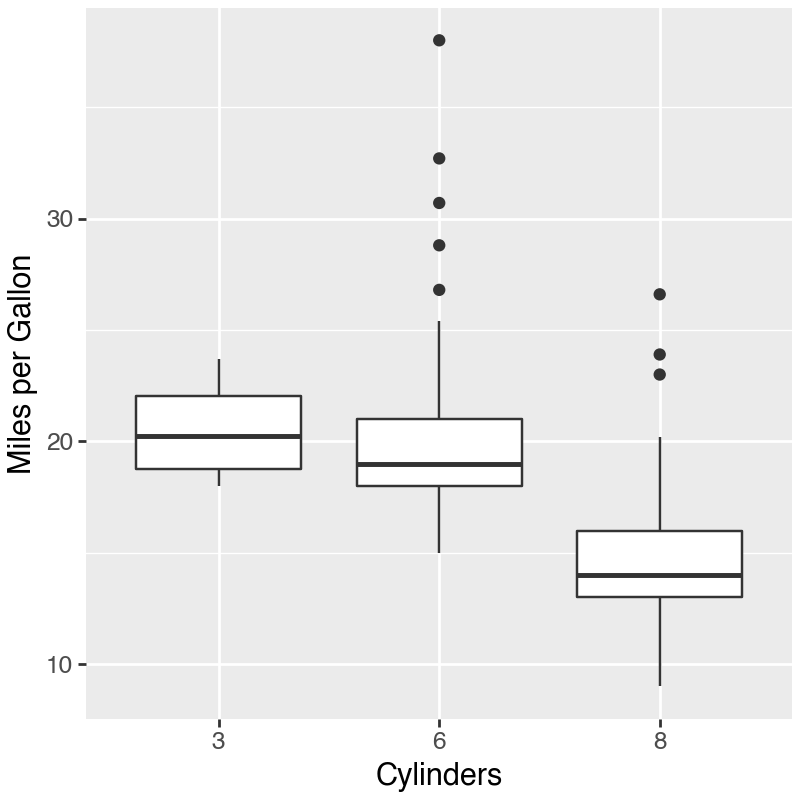

In [96]:
(
    ggplot(cars, aes('cylinders', 'mpg')) + 
    geom_boxplot() + 
    labs( x = 'Cylinders', y = 'Miles per Gallon') + 
    theme(figure_size=(4,4))
)


In this example, we are interested in whether there is a difference in the fuel consumption of cars depending on the number of cylinders in the car.

For this purpose, we will work with the following model:

$$
    y = \beta_0 + \beta_1 x_1 + \beta_2 x_2
$$

Here, $x_1$ and $x_2$ will be indicator variables.

* group '6 cylinders': $x_1 = 1$

* group '8 cylinders': $x_2 = 1$

We want to test the effect of both indicators at the same time:

* $H_0$: $\beta_1 = \beta_2 = 0$

* Full model: $\Omega$ is the space where all three $\beta$ can take any value.

* Reduced model $\omega$ is the space where only $\beta_0$ can take any value.

In Python, we can easily test this:

In [97]:
from statsmodels.stats.anova import anova_lm

full = smf.ols("mpg ~ cylinders", data=cars).fit()
reduced = smf.ols("mpg ~ 1", data=cars).fit()

In [98]:
anova_results = anova_lm(reduced, full)
print(anova_results)

   df_resid          ssr  df_diff      ss_diff          F        Pr(>F)
0     189.0  3240.182947      0.0          NaN        NaN           NaN
1     187.0  2042.371493      2.0  1197.811455  54.835945  1.816967e-19


From the result, we can see that the full model models the data significantly better than the reduced model containing only the intercept. Therefore, we can conclude that there is a difference in the means of the 3 groups.

## Diagnostic Plots

The assumptions of a mathematical model never hold exactly in practice. The questions for the practitioners are threefold: 

1) How badly are the assumptions violated on the dataset at hand? 

2) What are the implications for the claimed conclusions? 

3) How can the issue be addressed?


The assumptions of linear regressions are:

* The expected values of the response are a linear combinations of the explanatory variables

* Errors are identically and independently distributed.

* Errors follow a normal distribution.

We will see that two diagnostic plots will be helpful: the `residual plot` and the `Q-Q plot` of the residuals.

### Assessing non-linearity with residual plots

Non-linearity is typically revealed by noticing that the average of the residual depends on the predicted values. 

A smooth fit (`geom_smooth` default) on the residual plot can help spotting systematic non-linear dependencies.

In [109]:
np.random.seed(42)

n = 1000
x = np.random.uniform(0, 8, size = n)
noise = np.random.normal(0, 40, size = n)
y = x**3 + noise

In [113]:
nonLinDf = pd.DataFrame({
    'x' : x,
    'y' : y
})

nonLinDf.head()

,x,y
0,2.996321,34.008827
1,7.605714,386.553170
2,5.855952,216.021190
3,4.789268,134.275283
4,1.248149,24.336080


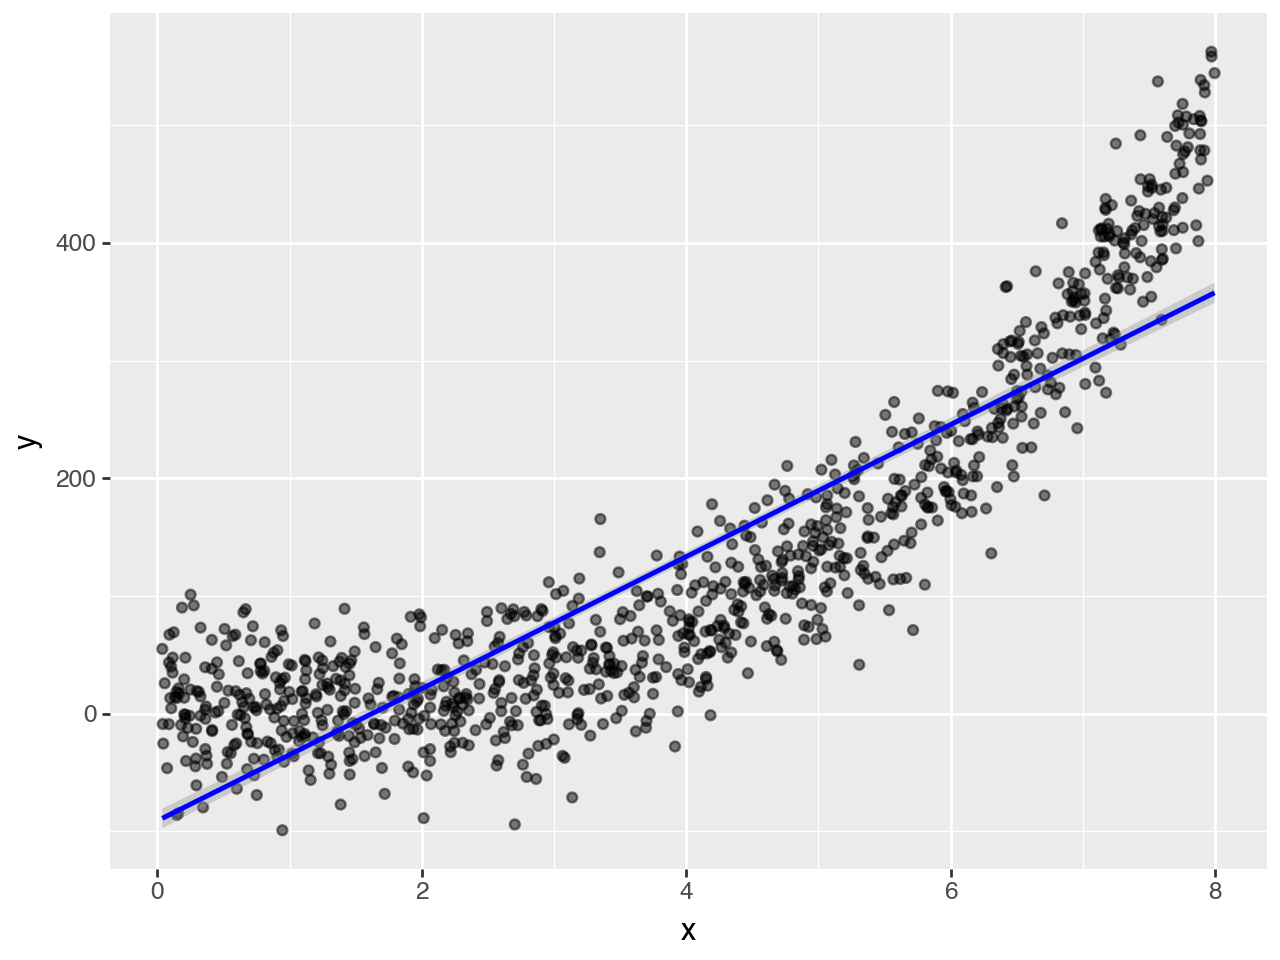

In [114]:
(
    ggplot(nonLinDf, aes('x','y')) + 
    geom_point(alpha = 0.5) + 
    geom_smooth(method = 'lm' , color = 'blue')
)

In [118]:
model = smf.ols('y ~ x', nonLinDf).fit()

nonLinDf['y_hat'] = model.predict(nonLinDf['x'])
nonLinDf['err'] = nonLinDf['y'] - nonLinDf['y_hat']
nonLinDf.head()

,x,y,y_hat,err
0,2.996321,34.008827,77.048053,-43.039225
1,7.605714,386.553170,335.647060,50.906110
2,5.855952,216.021190,237.480793,-21.459603
3,4.789268,134.275283,177.637055,-43.361773
4,1.248149,24.336080,-21.028950,45.365030


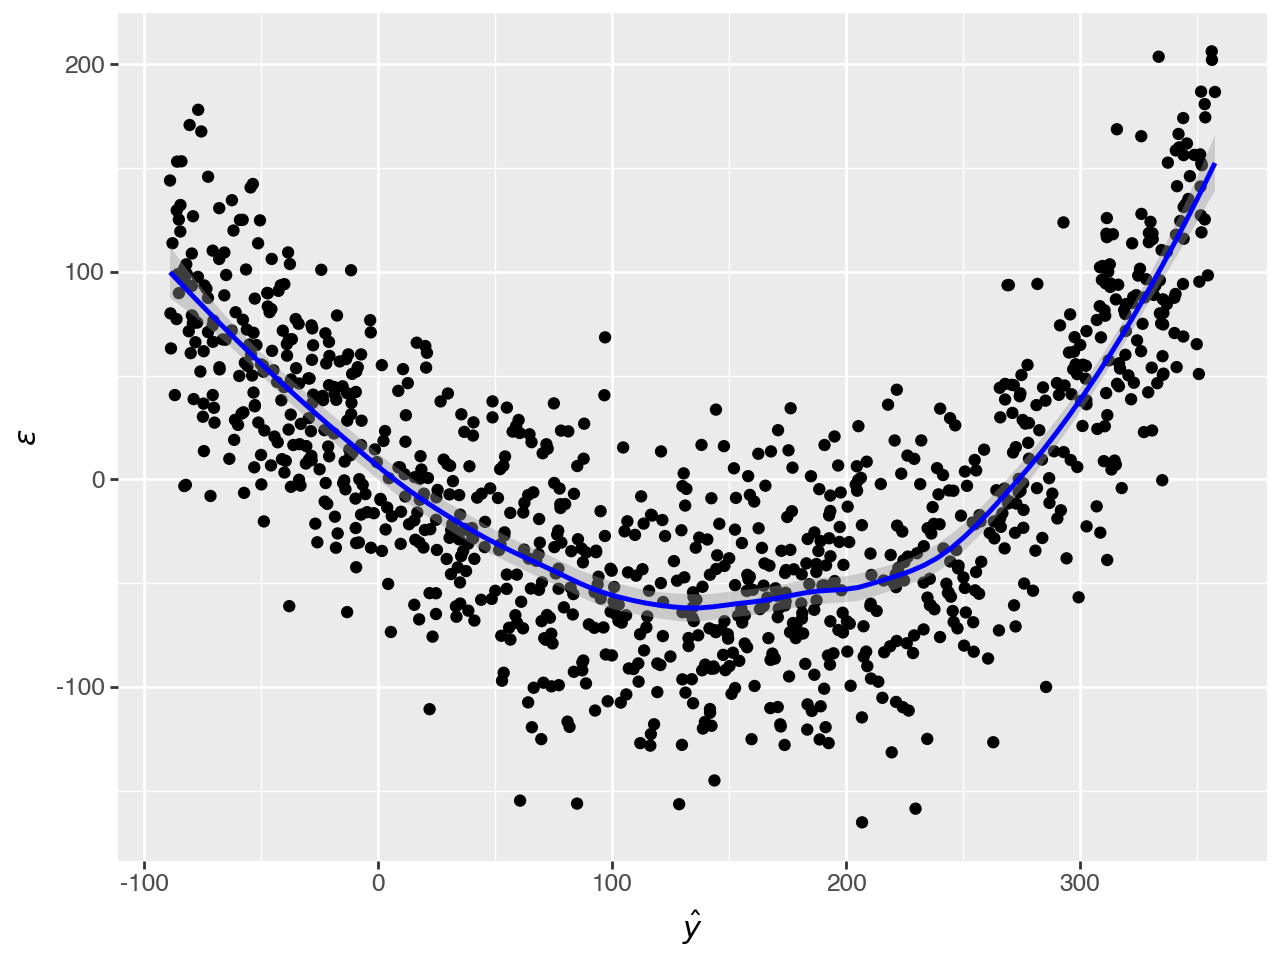

In [129]:
(
    ggplot(nonLinDf, aes('y_hat', 'err')) +
    geom_point() +
    geom_smooth(method='loess', span=0.4, color = 'blue') +
    labs(x = '$\hat y$', y = '$\epsilon$')
)

Here:
$\text{residual} = \epsilon = y - \hat y$



In the ideal case:

* residuals are randomly scattered around 0

* there is no systematic pattern


In the plot:

* the residuals exhibit a U-shaped pattern

<u>So what?</u> The implications of non-linearity depends on the application purposes:

* Predictions are suboptimal. They could be improved with a more complex model. However, they may be good enough for the use case, and they would not necessarily deteriorate on unseen data.

* Explained variance is underestimated.

* The i.i.d assumption is violated: The residuals depend on the predicted mean, suggesting that the errors depend on $E[y|x]$
 and therefore on each other. Therefore, statistical tests are flawed.

* Conditional dependencies can be affected. To see the latter assume a model in which two variables $x$
 and $y$
 depend on a common cause $z$
 in a non-linear fashion (eg. $y = z^2 + \epsilon$
 and $x = z^2 + \epsilon'$
). These two variables $x$
 and $y$
 are independent conditioned on their common cause $z$
. However, a linear regression of $y$
 on $x$
 and $z$
 would fail to discard the contribution of $x$
.


<u>What to do?</u> 

If non-linearity is revealed in the fit, one can either transform the explanatory variables or the response (eg log-transformation, powers, etc).

Note that the appropriate transformation is difficult to know in practice and finding it likely requires trying out several options.

The `I` in Python implements a few convenience functions to build such non-linear transformation on the fly while calling `smf.ols()`. 

For instance, the call: `smf.ols('y ~ x + I(x**2) + I(x**3)', data=df)` fits a polynomial of degree 3.

-------

### When error variance is not constant: Heteroscedasticity

It happens not so rarely that the variance of the residuals is not constant across all data points. This property is called heteroscedasticity. Heteroscedasticity violates the i.i.d assumption of the errors.

<u>Diagnostic plot</u>

The residual plots can help spotting when error variance depends on response mean. Here is a synthetic example:



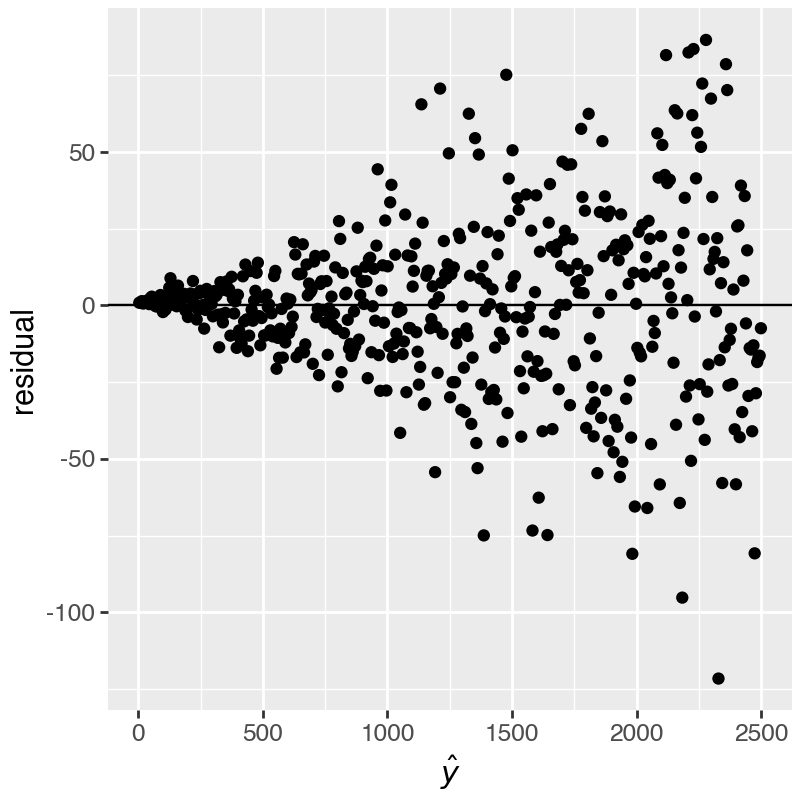

In [139]:
x = np.arange(1, 500)
y = np.random.normal(loc=5 * x, scale=0.1 * x)
df = pd.DataFrame({"x": x, "y": y})
m = smf.ols("y ~ x", data=df).fit()
df["y_hat"] = m.fittedvalues
df["resid"] = m.resid
(
    ggplot(df, aes("y_hat", "resid"))
    + geom_point()
    + geom_abline(intercept=0, slope=0)
    + labs(x='$\hat{y}$', y="residual")
    + theme(figure_size=(4, 4))
)

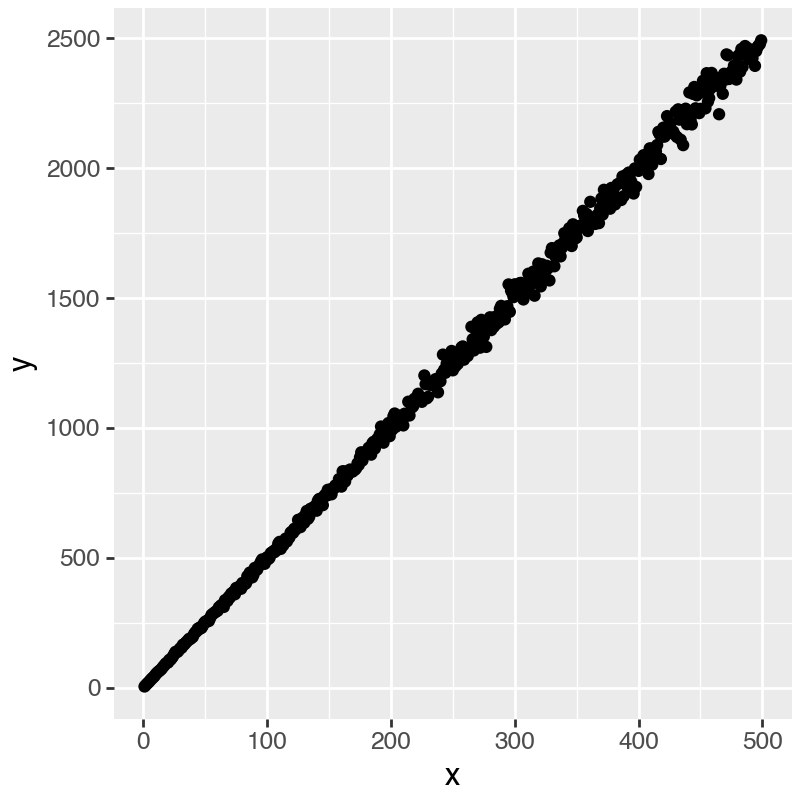

In [140]:
(
    ggplot(df, aes('x', 'y')) +
    geom_point() + 
    theme(figure_size=(4,4))
)

<u>So what?</u> 

For prediction, the problem may or not be a real issue. Indeed the fit can be driven by a few data points because the least squares errors give too much importance to the points with high noise. This is particularly a problem with low number of points in areas with large noise.

As the residuals are not i.i.d., the statistical tests are flawed.

<u>What to do?</u>

In case of heteroscedasticity, one can try to transform the response variable 
, such as: log-transformation, square root, or variance stabilizing transformation.

However, as before, the appropriate transformation is difficult to know in practice and finding it likely requires trying out several options. Alternatively, one can use methods with a different noise model. One possibility is to consider weighted least squares, when there is the possibility to estimate beforehand the relative error variances on the data. This is sometimes the case, for instance, if one has access to experimental uncertainties. Another direction is to use generalized linear models

-------

### Gaussianity: Q-Q-plot of the residuals

The Gaussian assumption of the errors is key to all statistical tests. An implication that the errors follow a Gaussian distribution is that the residuals also follow a Gaussian distribution.

We use here a Q-Q plot of the residuals against the normal distribution.

The plotnine function `stat_qq()` and its companion `stat_qq_line()` generate Q-Q plot against a Gaussian fitted to the input vector.

We do not have to worry about the mean and the standard deviation of the input vector. Here is a “good” example based on simulated data. The residuals, by construction, have a mean 0, but their variance is not necessarily 1. If they follow a Gaussian distribution, the Q-Q plot should show a line whose slope equals the standard deviation of the residuals. To check this visually in a robust way, stat_qq_line() draws the line passing through the first and third quartiles of the data.

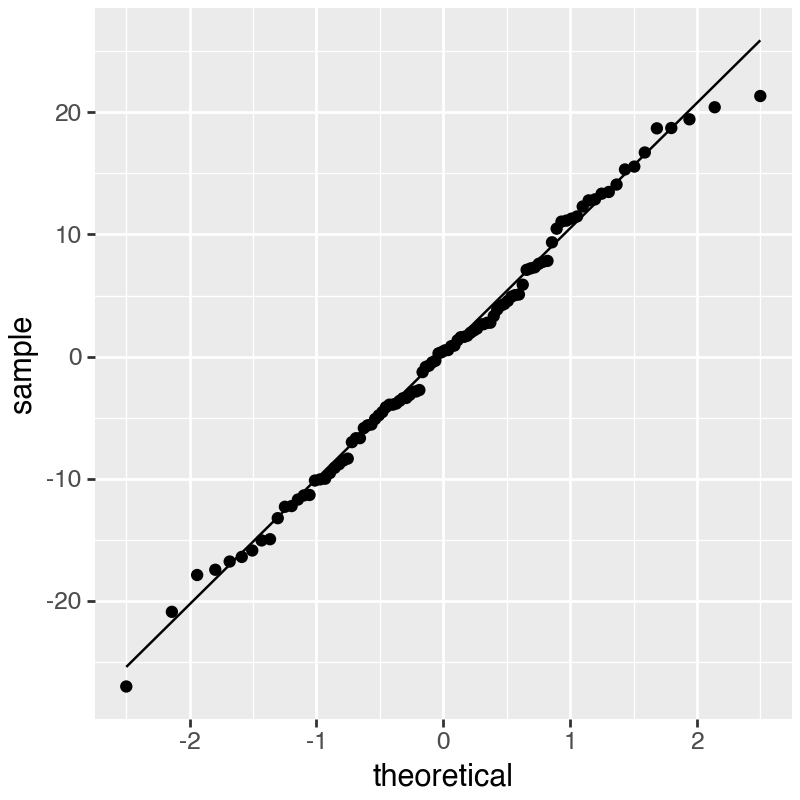

In [148]:
np.random.seed(0)

x = np.arange(1,101)
y = np.random.normal(loc=5 * x, scale=10)

df = pd.DataFrame({
  "x": x,
  "y": y})
m = smf.ols("y ~ x", data=df).fit()
df_resid = pd.DataFrame({"resid": m.resid})
(
    ggplot(df_resid, aes(sample="resid"))
    + stat_qq()
    + stat_qq_line()
    + theme(figure_size=(4, 4))
)

And here is a “bad” example based on a simulated example, in which the errors are Student t-distributed with degree of freedom 1:

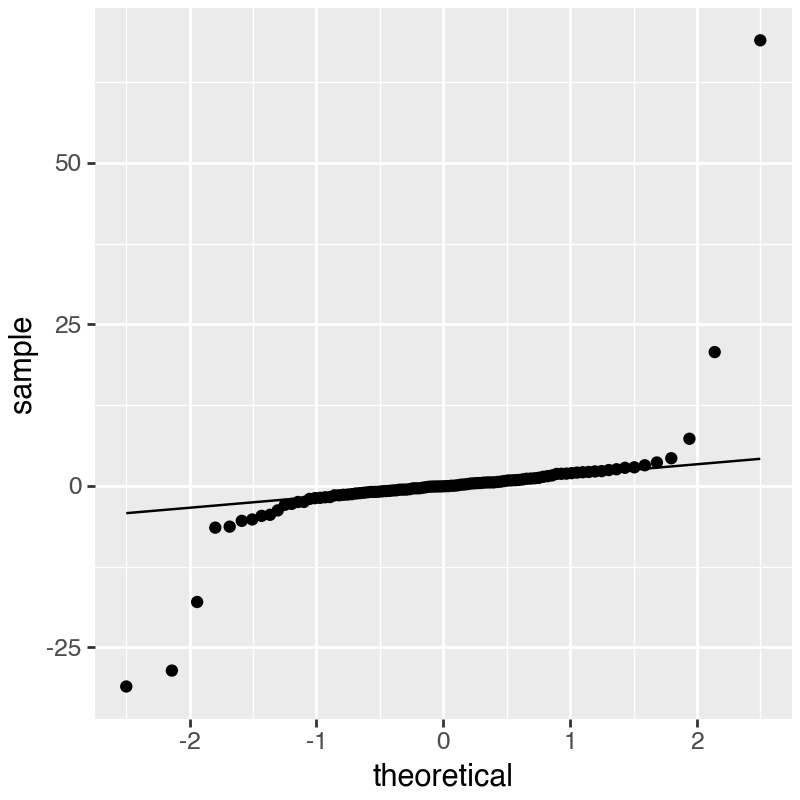

In [149]:
np.random.seed(0)
df = pd.DataFrame({
  "x":  np.arange(1, 101),
  "y": np.random.standard_t(df=1, size=100)})
m = smf.ols("y ~ x", data=df).fit()
df_resid = pd.DataFrame({"resid": m.resid})
(
    ggplot(df_resid, aes(sample="resid"))
    + stat_qq()
    + stat_qq_line()
    + theme(figure_size=(4, 4))
)

<u>So what?</u> 

If Gaussianity of the residuals is not satisfied, this means that the noise model is wrong. This can have the following practical implications:

* With enough data, the regression lines might not be too severely affected the least squares estimates converge to the expected values. Applying least squares to fit and predict does not depend on the Gaussian assumption!

* Hypothesis testing can be flawed.

<u>What to do ? </u>

 We may work with fundamentally non-Gaussian data (like Poisson distributed data, which are count data), or data with long tails and outliers. If one has an idea of what could be a better noise model, consider a generalized linear model with another distribution. Alternatively, use case resampling to estimate confidence intervals.




---------

# To remember

Now you should:

* Understand linear regression as a method to test conditional dependence ($p(y|x) \neq p(y)$
) and estimate the effects of variables

* Interpret regression coefficients ($\beta$
) and $R^2$ 

* Explain how multivariate regression controls for confounding

* List the four key assumptions of Linear Regression

* Diagnose assumption violations using residual plots and Q-Q plots

* Apply statistical tests correctly: Use t-tests for individual coefficients and F-tests (ANOVA) for comparing nested models.